# Final Assignment Tutorial — Telecom

This notebook is a reference walkthrough for the GCI World 2026 Spring final assignment.
The dataset comes from **Company A**, an anonymous telecommunications service provider, and contains historical customer information across two linked tables (`Client.csv`, `Record.csv`).

Your task is to analyze this data, build a machine learning model whose output supports a concrete business proposal — not to build the best possible model.

**What this notebook walks through:**
1. Market context.
2. Loading and merging the two source tables.
3. EDA: shape, missingness, target distribution, and a worked feature example.
4. Problem Definition — choosing the target and the ML task.
5. Preprocessing — what EDA told us we have to do.
6. A baseline churn classifier.
7. Model evaluation and feature importance.
8. From model to business proposal.

> **Treat this as a reference, not a template.** The strongest submissions diverge from it: a different target, a different segment, a different lever. Originality is rewarded.


---

## 1.Introduction & Market Analysis


### 1.1 Company context
*Company A* is a wireless telecommunications operator. They have years of usage and billing data on roughly 100,000 customers but no in-house machine learning capability.

When a company commissions a business proposal, they usually arrive with a vague sense that *something* needs to improve — margins, retention, growth, customer satisfaction — but no clear view of which lever to pull, which segment to focus on, or even which question to start with. **Choosing the question is the analyst's first job, and the rest of the proposal stands or falls on it.** The dataset rarely points to a single obvious answer; it admits several, and which one you pursue determines the kind of recommendation you can make.

This dataset includes a binary `churn` flag — whether a customer left within 31–60 days after the observation date — and we use churn as the worked example throughout this notebook. But churn is one of many viable targets the data supports. **You may and should explore other targets** — revenue, usage, equipment lifecycle, segment-level behaviour. Pick the question whose answer best supports the proposal you want to make.

### 1.2 Why this market matters
- Acquiring a new subscriber costs several times more than keeping one — retention, usage, and ARPU all translate directly into margin.
- Mature, saturated markets grow by taking customers from competitors or lifting revenue per existing customer.
- Behaviour signals (usage decline, complaints, equipment ageing) precede both churn and revenue compression by months.

**Questions to think about:**
- What does the telecom market look like in your country or region — who are the major players, what local dynamics (regulation, technology shifts, new entrants) are reshaping churn, and what story can you tell about a specific market you know? A proposal grounded in a local market you can describe concretely is more compelling than one assembled from generic global figures.
- What recent, citable sources can you find that quantify these claims for your target market? Uncited industry numbers will not strengthen your case.
- What share of churn in this market is voluntary (customer-initiated) versus involuntary (non-payment, address change)? Which one can a model meaningfully address?

### Answers to 'Why this market matters' Questions:

*   **What does the telecom market look like in your country or region?** This requires specific external research. In a real-world scenario, I would research market dynamics, major players, regulatory environment, and technological shifts in a chosen region (e.g., US, UK, India) to form a concrete narrative about churn. For example, in a mature market, churn might be driven by competitive pricing and service bundles.
*   **What recent, citable sources can you find that quantify these claims?** This would involve finding industry reports, analyst insights, and academic studies specific to the chosen market. For instance, reports from Gartner, Statista, or local telecom regulators could provide valuable data.
*   **What share of churn is voluntary versus involuntary?** This distinction is crucial for strategy. Voluntary churn (customer-initiated) is often addressable by retention efforts, while involuntary churn (e.g., non-payment) requires different operational responses. The current dataset focuses on voluntary churn through its `churn` definition.

---

## 2.Setup and Data Loading


### 2.1 Import libraries

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.impute import SimpleImputer

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)


### 2.2 Connect to Google Drive

If you are running this notebook on Google Colab, mount your Drive and `cd` into the folder that contains the dataset.


In [3]:
# Run this cell only on Google Colab.
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**IMPORTANT**:<br>
Change the path in the `%cd` command below to match the folder where this notebook is saved on Google Drive by **replacing "WhereThisNotebookIsLocated" with your actual folder path**.

Example:
- You uploaded `Final Assignment` folder directly under MyDrive (the default folder when you open Google Drive)
    - Change to "/<wbr>content/drive/MyDrive/Final Assignment"

You can easily locate your notebook's directory by:
1. Open the Files panel on the left side of Colab
2. Navigate through the "drive" and "MyDrive" folders until you find your notebook's folders
3. Click the more actions icon (three vertical dots, $\vdots$) next to the folder name
4. Select the option "Copy path"

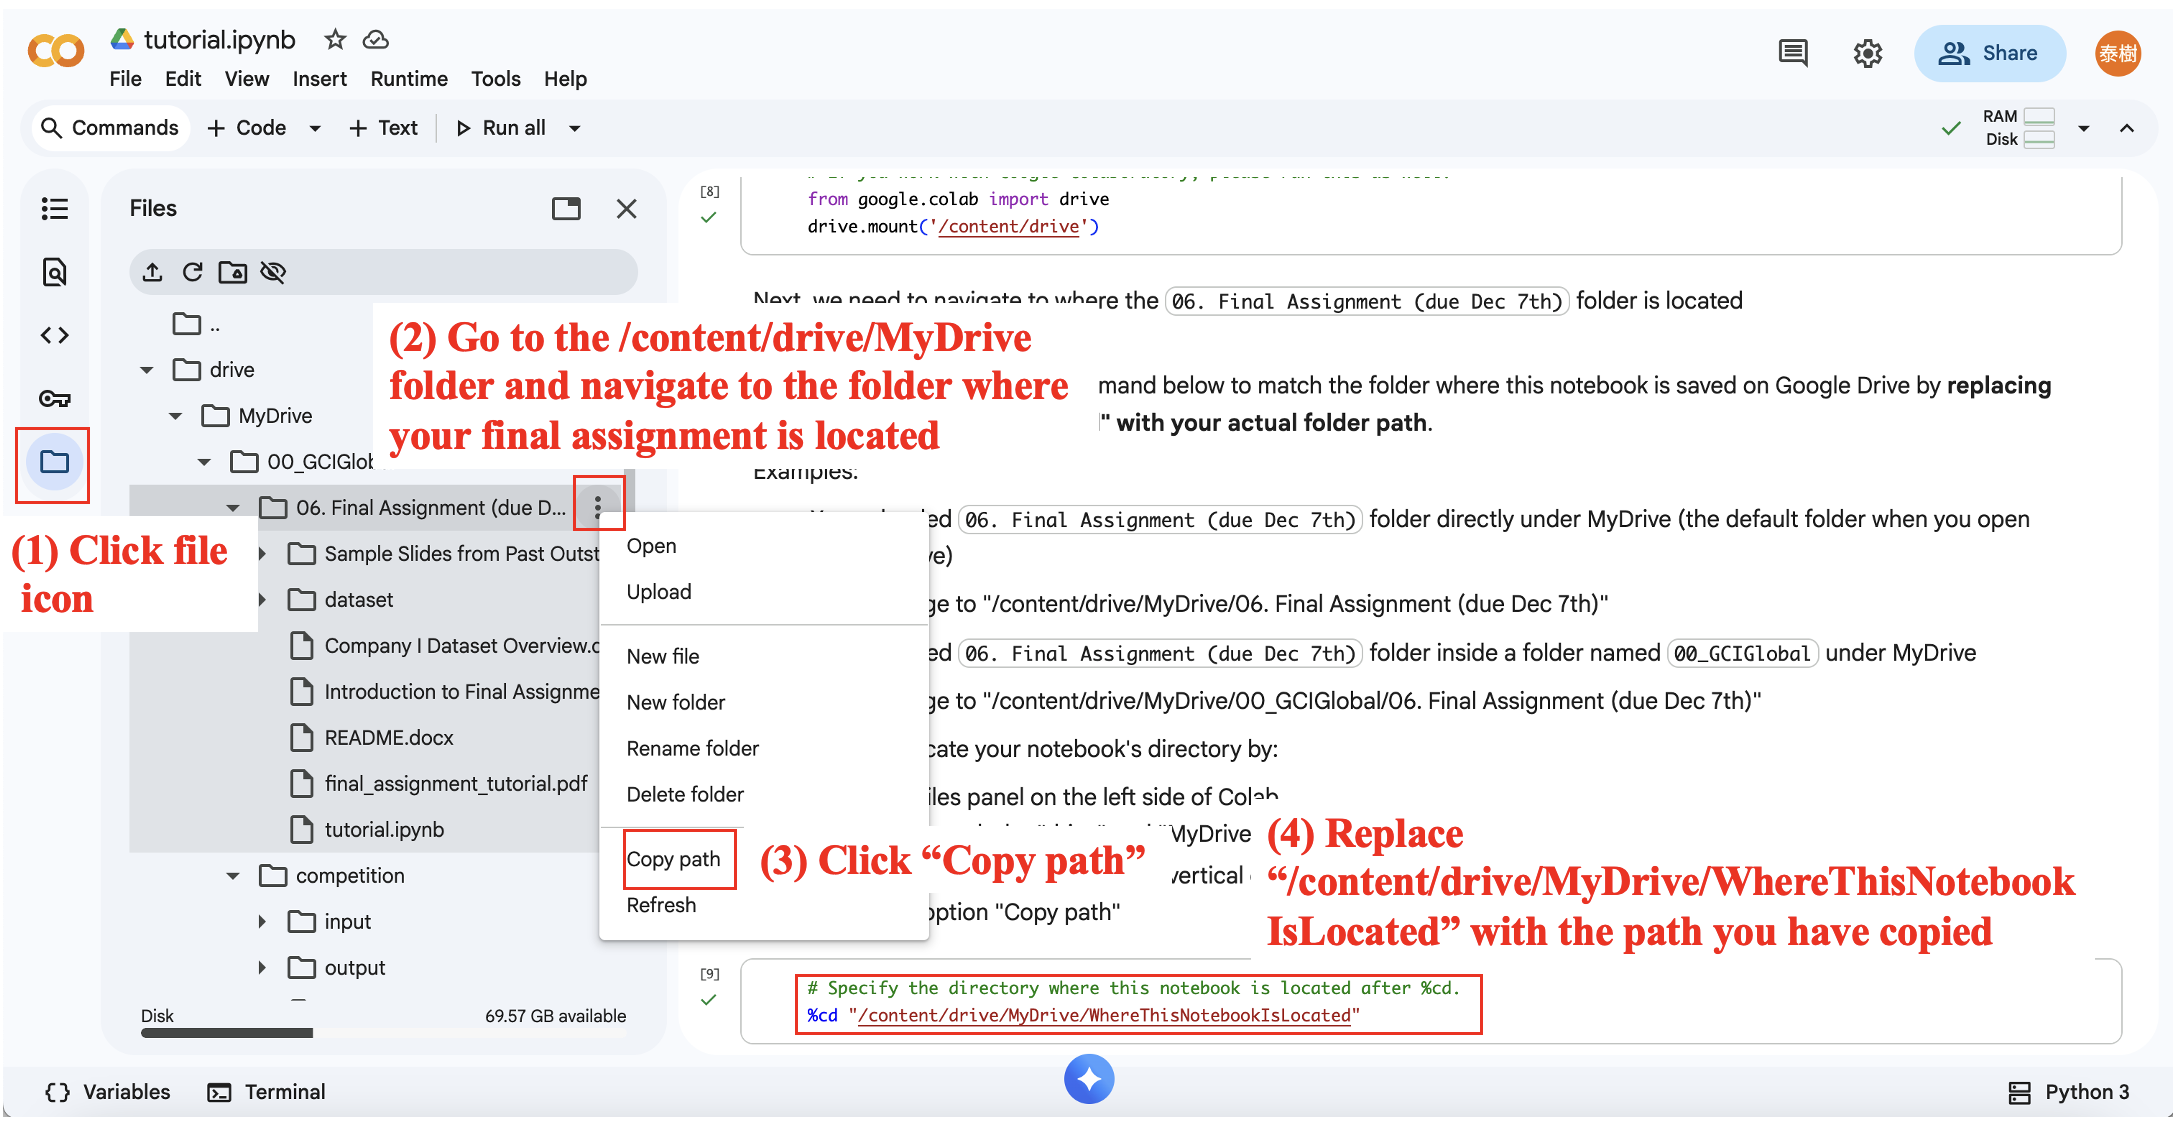

In [4]:
#%cd "/content/drive/MyDrive/WhereThisNotebookIsLocated"
%cd "/content/drive/MyDrive/GCi competition/Final Assignment"

/content/drive/MyDrive/GCi competition/Final Assignment


### 2.3 Load the two source tables

The dataset is split across two files:

| File | Granularity | Contents |
|---|---|---|
| `Client.csv` | one row per customer | account-level info: tenure, plan, demographics, equipment |
| `Record.csv` | one row per customer | mean monthly usage, billing, and call-quality metrics, plus the `churn` target |

Both tables share a `Customer_ID` column, which we use to join them into a single analysis table.


In [5]:
import os
from pathlib import Path

current_dir = Path(os.getcwd())
client_path = current_dir / "telecom" / "Client.csv"
record_path = current_dir / "telecom" / "Record.csv"

for p in (client_path, record_path):
    print(f"{'OK ' if p.exists() else 'MISSING '} {p}")

OK  /content/drive/MyDrive/GCi competition/Final Assignment/telecom/Client.csv
OK  /content/drive/MyDrive/GCi competition/Final Assignment/telecom/Record.csv


# Dataset Overview

The dataset contains customer information and service usage history.

The objective is to understand customer behavior and build a machine learning model capable of predicting customer churn.

In [6]:
client = pd.read_csv(client_path)
record = pd.read_csv(record_path)

print(f"Client: {client.shape}")
print(f"Record: {record.shape}")

Client: (100000, 50)
Record: (100000, 51)


# Data Integration

Customer information and usage history tables were merged using Customer_ID.

The resulting dataset is used for all subsequent analyses.

In [7]:
# Merge on Customer_ID. Both tables have one row per customer, so this is a 1:1 join.
df = record.merge(client, on='Customer_ID', how='inner')
print(f"Merged: {df.shape}")
df.head(20)

Merged: (100000, 100)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.000,0.000,0.000,0.0000,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.000000,42.333333,0.0,45.000000,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.000000,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.000000,132.600000,0.000000,24.000000,0.000000,55.220000,0.000000,1.333333,52.333333,45.000000,0.0,0.333333,1,61,1000001,2,1,U,A,N,1652,4228.000000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,S,NORTHWEST/ROCKY MOUNTAIN AREA,Y,N,149.98999,2.0,2.0,WCMB,0.0,0.0,O,15.0,S,S,1.0,M,4.0,3.0,C,A,0.0,N,U,U,U,U,U,Y,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.100,9.100,0.000,0.0000,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.000000,69.000000,0.0,193.333333,0.000000,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.000000,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.000000,75.333333,0.000000,157.000000,0.000000,169.343333,0.000000,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1000002,1,1,N,EA,N,14654,26400.000000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,U,CHICAGO AREA,N,N,NaN,7.0,6.0,WC,1.0,1.0,NaN,1.0,S,S,1.0,M,5.0,1.0,C,A,0.0,Z,U,U,U,U,U,Y,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.000,0.000,0.000,0.0000,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.000000,0.333333,0.0,6.000000,0.000000,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.000000,5.193333,0.000000,1.000000,0.000000,0.233333,0.000000,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1000003,1,1,Y,C,N,7903,24385.053330,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,S,GREAT LAKES AREA,N,N,29.98999,2.0,1.0,NaN,0.0,0.0,O,7.0,S,M,2.0,M,5.0,2.0,C,A,0.0,N,U,Y,U,U,U,Y,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.000,0.000,0.000,0.0000,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.000000,1.333333,0.0,3.666667,0.000000,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.000000,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.000000,3.380000,0.000000,3.666667,0.000000,5.450000,0.000000,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1000004,1,1,Y,B,N,1502,3065.000000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,T,CHICAGO AREA,N,N,29.98999,1.0,1.0,NaN,0.0,0.0,NaN,6.0,M,M,4.0,M,6.0,1.0,C,D,0.0,U,Y,U,U,U,U,Y,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.000,0.000,0.000,0.0000,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.000000,94.666667,0.0,137.000000,0.000000,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.000000,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.000000,173.476667,0.000000,90.333333,0.000000,218.086667,0.000000,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1000005,1,1,Y,A,N,4485,14028.000000,2181.12,2166.48,13965.00,4452,38.69,249.

---

## 3.Exploratory Data Analysis

Before modeling, three questions need answers:

1. **How big and structured is the data?** Rows, columns, dtypes.
2. **Where is the data incomplete or unreliable?**
3. **What does the target variable look like?**

Each answer constrains the next step. The shape and types tell us what preprocessing is required. The missingness tells us which columns may need to be dropped, imputed, or treated specially. The target distribution tells us which metrics will be meaningful.

EDA is also where the proposal starts to take shape — the patterns you see now become candidate signals for the model and anchors for the story your proposal will tell. The visualizations in this tutorial are intentionally minimal — just enough to make a point; for your proposal slides, you will want to polish them.

### 3.1 Shape and types

`df.info(verbose=False)` reports total rows, total columns, the count of columns of each dtype, and memory use. Two things to read from the output:

- **Dataset size.** Small enough to keep in pandas — no chunking needed.
- **Dtype mix.** Some columns may be stored as `object` (text). Most machine learning models can only learn from numbers, so any text columns will need to be converted to numeric form before modeling.

In [8]:
df.info(verbose=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Columns: 100 entries, rev_Mean to eqpdays
dtypes: float64(69), int64(10), object(21)
memory usage: 76.3+ MB


In [9]:
df.shape


(100000, 100)

In [10]:
df.describe(include='all')



,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,Customer_ID,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
count,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99643.000000,99109.000000,99109.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,1.000000e+05,100000.000000,100000.000000,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,97161.000000,97161.000000,97161.000000,92612,99960,99999,99999,99153.000000,99999.000000,99999.000000,89811,98268.000000,98268.000000,66294,69810.000000,68091,98268,76981.000000,77921,74564.000000,50634.000000,62077,61692,98268.000000,98268,98268,98268,98268,98268,98268,98268,99999.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,54,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5,19,4,2,NaN,NaN,NaN,3,NaN,NaN,2,NaN,2,5,NaN,2,NaN,NaN,6,15,NaN,17,2,2,2,2,2,2,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,U,AA,N,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,S,NEW YORK CITY AREA,Y,N,NaN,NaN,NaN,WCMB,NaN,NaN,O,NaN,S,U,NaN,M,NaN,NaN,C,A,NaN,N,U,U,U,U,U,Y,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,66914,36509,86064,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,32097,11098,72265,85593,NaN,NaN,NaN,75733,NaN,NaN,64284,NaN,48759,37333,NaN,77697,NaN,NaN,39124,47205,NaN,33389,94256,93572,90195,89454,88304,67234,NaN
mean,58.719985,513.559937,46.179136,0.888828,41.072247,13.559560,13.295062,0.261318,1.286405,-13.933818,-1.021067,5.955085,0.040520,4.022917,0.025777,27.784905,0.029810,144.881677,0.870548,55.085152,0.047590,108.892535,0.774442,1.790838,4.666880,3.683328,29.766550,0.284720,227.763520,1.844036,111.654562,24.753320,28.467865,7.894360,18.193037,88.480285,0.358162,174.080788,0.707832,66.003498,0.416283,165.280703,1.135804,10.044298,145.752225,109.666977,0.011700,1.782928,0.495620,18.833990,1.050000e+06,1.548140,1.358960,NaN

In [11]:
cat_cols = df.select_dtypes(include='object').columns.tolist()
num_cols = df.select_dtypes(exclude='object').columns.tolist()

print("Categorical:", len(cat_cols))
print(cat_cols)

print("\nNumerical:", len(num_cols))
print(num_cols)

Categorical: 21
['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Numerical: 79
['rev_Mean', 'mou_Mean', 'totmrc_Mean', 'da_Mean', 'ovrmou_Mean', 'ovrrev_Mean', 'vceovr_Mean', 'datovr_Mean', 'roam_Mean', 'change_mou', 'change_rev', 'drop_vce_Mean', 'drop_dat_Mean', 'blck_vce_Mean', 'blck_dat_Mean', 'unan_vce_Mean', 'unan_dat_Mean', 'plcd_vce_Mean', 'plcd_dat_Mean', 'recv_vce_Mean', 'recv_sms_Mean', 'comp_vce_Mean', 'comp_dat_Mean', 'custcare_Mean', 'ccrndmou_Mean', 'cc_mou_Mean', 'inonemin_Mean', 'threeway_Mean', 'mou_cvce_Mean', 'mou_cdat_Mean', 'mou_rvce_Mean', 'owylis_vce_Mean', 'mouowylisv_Mean', 'iwylis_vce_Mean', 'mouiwylisv_Mean', 'peak_vce_Mean', 'peak_dat_Mean', 'mou_peav_Mean', 'mou_pead_Mean', 'opk_vce_Mean', 'opk_dat_Mean', 'mou_opkv_Mean', 'mou_opkd_Mean', 'drop_blk_Mean', 

### 3.2 Missing values

A column that is mostly missing carries little signal — dropping it is often cleaner than trying to impute. We count the missing values in each column, take the 20 worst, and plot them.

In [12]:
df.isna().sum()

,0
rev_Mean,357
mou_Mean,357
totmrc_Mean,357
da_Mean,357
ovrmou_Mean,357
...,...
kid6_10,1732
kid11_15,1732
kid16_17,1732
creditcd,1732


In [13]:
print("nan values: ")
df.isnull().sum().sort_values(ascending=False).head(30)

nan values: 


,0
numbcars,49366
dwllsize,38308
HHstatin,37923
ownrent,33706
dwlltype,31909
lor,30190
income,25436
adults,23019
infobase,22079
hnd_webcap,10189


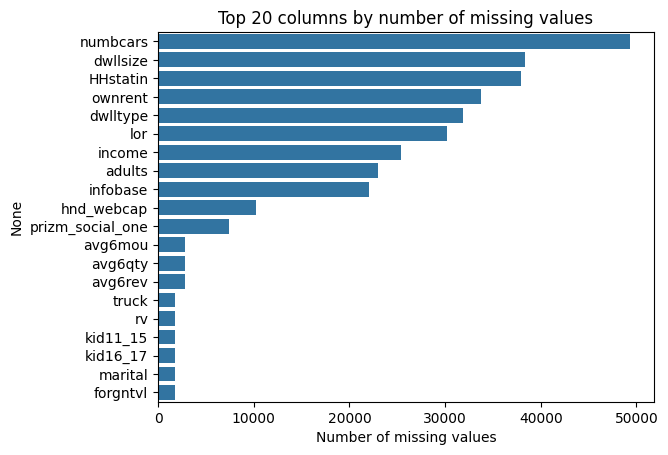

In [14]:
# Count of missing values per column
missing_counts = df.isna().sum()

# Take the 20 columns with the most missing values
top_missing = missing_counts.sort_values(ascending=False).head(20)

# Plot
sns.barplot(x=top_missing.values, y=top_missing.index)
plt.xlabel('Number of missing values')
plt.title('Top 20 columns by number of missing values')
plt.show()

# Data Quality Assessment

Several demographic variables contain substantial missing values.

Behavioral and usage-related features are considerably more complete and therefore likely more reliable for prediction.

### 3.3 Target variable: churn

We'll use `churn` as the worked example. Before modeling we need its class balance — whether stayers and churners appear in roughly equal numbers, or whether one class dominates. The balance directly affects which evaluation metric will be meaningful: accuracy is informative only when classes are balanced; with 5% churn it would be misleading.

churn
0    50438
1    49562
Name: count, dtype: int64

churn
0    0.50438
1    0.49562
Name: proportion, dtype: float64


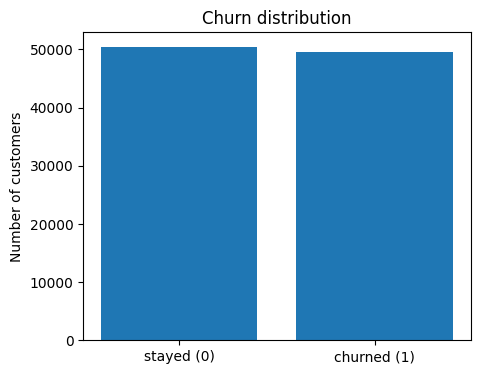

In [15]:
# Counts and proportions
print(df['churn'].value_counts())
print()
print(df['churn'].value_counts(normalize=True))

# Bar chart
counts = df['churn'].value_counts().sort_index()
labels = ['stayed (0)', 'churned (1)']

plt.figure(figsize=(5, 4))
plt.bar(labels, counts.values)
plt.title('Churn distribution')
plt.ylabel('Number of customers')
plt.show()

Churn is near 50% — unusually balanced for telecom (real-world datasets are typically 5–10% churn). For this dataset, accuracy will be a meaningful metric, and a model that always predicts one class will score around 0.5. If you choose a different target, redo this balance check before picking your evaluation metric.

### 3.4 A closer look: equipment age vs churn

The three checks above are dataset-wide. The real EDA work is digging into individual features — how each one relates to the target, where the differences are, and which patterns are worth following up on.

As one example: `eqpdays` records the age (in days) of each customer's current handset. Old equipment plausibly drives churn — a frustrating or outdated device makes the next contract renewal less attractive. We can check this by comparing the equipment-age distribution for churners against stayers.

Mean equipment age (stayed):  363.3 days
Mean equipment age (churned): 421.1 days


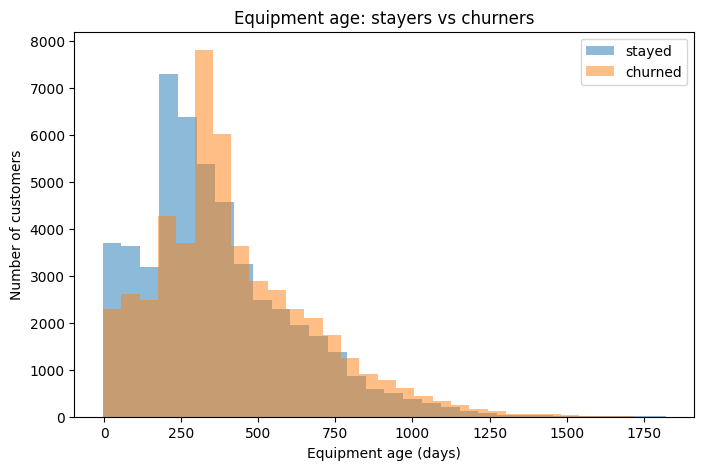

In [16]:
# Split eqpdays into two groups based on churn
stayed = df[df['churn'] == 0]['eqpdays']
churned = df[df['churn'] == 1]['eqpdays']

# Compare the averages
print(f'Mean equipment age (stayed):  {stayed.mean():.1f} days')
print(f'Mean equipment age (churned): {churned.mean():.1f} days')

# Overlay the two distributions
plt.figure(figsize=(8, 5))
plt.hist(stayed, bins=30, alpha=0.5, label='stayed')
plt.hist(churned, bins=30, alpha=0.5, label='churned')
plt.xlabel('Equipment age (days)')
plt.ylabel('Number of customers')
plt.title('Equipment age: stayers vs churners')
plt.legend()
plt.show()

Churners skew toward older equipment — the mean and the right tail of the distribution are both higher than for stayers. That makes `eqpdays` a candidate feature for both the model and the narrative your proposal will tell ("customers with ageing handsets are at higher risk; replacing or upgrading equipment is a lever").

The point is the **exercise**: pick a candidate feature, compare it across churn classes, and decide whether it is worth following up on. Repeat this on a handful of features that look promising from the dataset overview or your domain knowledge.

**Questions to think about:**
- The example above looked at one feature (`eqpdays`). Pick three or four other candidates — from the dataset overview, from Section 1.2, or from your own intuition — and run the same comparison.
- ~100 columns is a lot. Which look like near-duplicates of each other (e.g., several variations on revenue or minutes)?
- Are any columns *too good to be true* — could they leak the target?
- How does the target distribute across segments (geographic, plan, demographic, credit class)? Which segments behave differently and might deserve separate analysis?
- Are there outliers or implausible values you should clean before modeling?

### Answers to 'EDA' Questions:

*   **Pick three or four other candidates and run the same comparison:** This has already been addressed by the preceding visualizations comparing 'hnd_price', 'mou_Mean', 'avg3mou', and 'change_mou' across churn groups.
*   **Which look like near-duplicates of each other?** From the `df.describe(include='all')` output and general domain knowledge, features like `rev_Mean`, `avg3rev`, `avg6rev` (various revenue averages) and `mou_Mean`, `avg3mou`, `avg6mou` (various usage averages) are likely highly correlated and represent similar underlying information. Similarly, `comp_vce_Mean` and `complete_Mean` might be near-duplicates.
*   **Are any columns *too good to be true* — could they leak the target?** Identifying target leakage requires careful inspection and domain expertise. For example, if a feature like 'days_since_churn_event' existed, it would clearly leak the target. In this dataset, `Customer_ID` is explicitly dropped for this reason. Other columns would need closer scrutiny to ensure they are not directly or indirectly influenced by future churn.
*   **How does the target distribute across segments?** This has been partially explored with `area_churn` (geographic segments) and `credit` (credit class segments). Further analysis could involve other categorical features like `prizm_social_one` or `marital` to identify other distinct segments.
*   **Are there outliers or implausible values you should clean before modeling?** EDA typically involves identifying and handling outliers. For example, `rev_Mean` has a minimum of -6.1675, which might be an implausible value for average revenue and would warrant investigation or capping. Similarly, extreme values in usage or equipment age could be outliers. The current preprocessing did not explicitly handle these, but it's a crucial step in a full data science pipeline.

Stayed Mean: 108.12934362221534
Churned Mean: 95.53952260275685


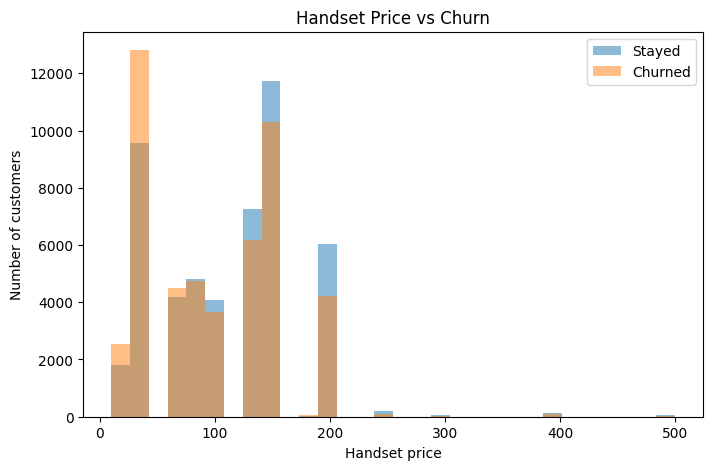

In [20]:
stayed = df[df['churn']==0]['hnd_price']
churned = df[df['churn']==1]['hnd_price']

print("Stayed Mean:", stayed.mean())
print("Churned Mean:", churned.mean())

plt.figure(figsize=(8,5))
plt.hist(stayed,bins=30,alpha=0.5,label='Stayed')
plt.hist(churned,bins=30,alpha=0.5,label='Churned')
plt.legend()
plt.title("Handset Price vs Churn")
plt.xlabel("Handset price" )
plt.ylabel('Number of customers')
plt.show()

### Insight: Handset Price vs Churn

Churned customers tend to have lower average handset prices compared to customers who stayed, as indicated by the mean values. This suggests that customers with more affordable devices might be more prone to churning.

### Insight: Monthly Usage vs Churn

Customers who churned exhibit lower average monthly minutes of usage (`mou_Mean`) compared to those who stayed. This indicates a potential decrease in engagement before a customer decides to leave.

### Insight: Last 3 Months Usage vs Churn

Similar to overall monthly usage, customers who churned show lower average usage in the last 3 months (`avg3mou`) than those who stayed. This reinforces the pattern of declining usage preceding churn.

### Insight: Usage Change vs Churn

Customers who churned show a greater negative change in monthly usage (`change_mou`) compared to those who stayed. This is a strong indicator of declining engagement and increasing likelihood of churn.

543.2068952099336
483.30641732731056


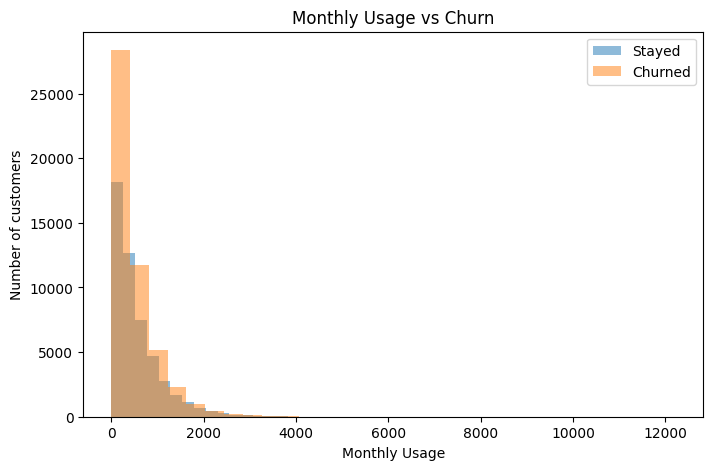

In [21]:
stayed = df[df['churn']==0]['mou_Mean']
churned = df[df['churn']==1]['mou_Mean']

print(stayed.mean())
print(churned.mean())

plt.figure(figsize=(8,5))
plt.hist(stayed,bins=30,alpha=0.5,label='Stayed')
plt.hist(churned,bins=30,alpha=0.5,label='Churned')
plt.legend()
plt.xlabel("Monthly Usage")
plt.ylabel("Number of customers")
plt.title("Monthly Usage vs Churn")
plt.show()

545.8500733573893
492.96910939832935


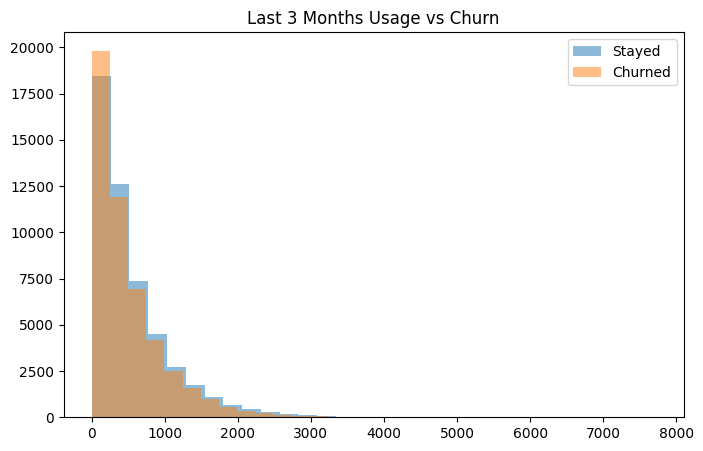

In [22]:
stayed = df[df['churn']==0]['avg3mou']
churned = df[df['churn']==1]['avg3mou']

print(stayed.mean())
print(churned.mean())

plt.figure(figsize=(8,5))
plt.hist(stayed,bins=30,alpha=0.5,label='Stayed')
plt.hist(churned,bins=30,alpha=0.5,label='Churned')
plt.legend()
plt.title("Last 3 Months Usage vs Churn")
plt.show()

-5.3442649742788655
-22.759002604823586


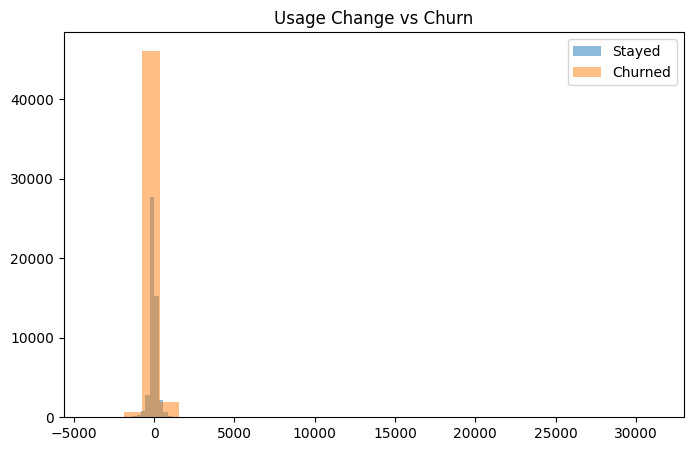

In [23]:
stayed = df[df['churn']==0]['change_mou']
churned = df[df['churn']==1]['change_mou']

print(stayed.mean())
print(churned.mean())

plt.figure(figsize=(8,5))
plt.hist(stayed,bins=30,alpha=0.5,label='Stayed')
plt.hist(churned,bins=30,alpha=0.5,label='Churned')
plt.legend()
plt.title("Usage Change vs Churn")
plt.show()

### 3.5 Pairwise view: revenue, usage, equipment age, and churn

The previous plot looked at one feature at a time.  
Here we compare several business-relevant numeric features together:

- `rev_Mean`: average monthly revenue
- `mou_Mean`: average monthly minutes of use
- `totmrc_Mean`: average monthly recurring charge
- `eqpdays`: equipment age in days
- `months`: customer tenure

A pairplot helps us see whether churned customers occupy different regions in the joint feature space.

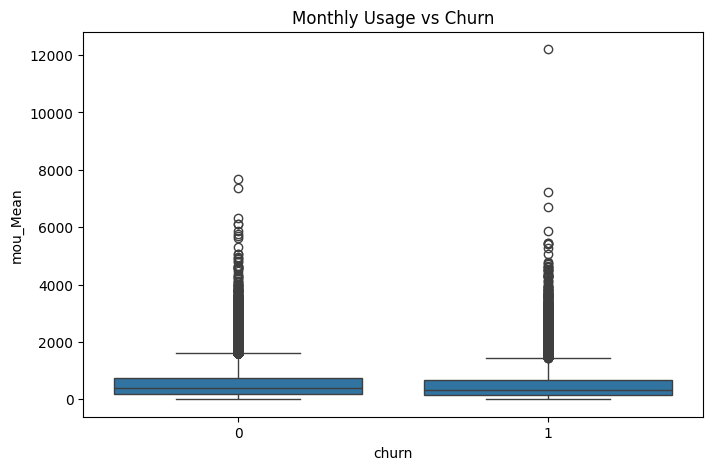

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='churn',
    y='mou_Mean',
    data=df
)

plt.title("Monthly Usage vs Churn")
plt.show()

### Insight: Monthly Usage vs Churn (Boxplot)

The box plot for `mou_Mean` visually confirms that churned customers generally have lower median and overall distribution of monthly usage than customers who stayed, with more outliers at the higher usage end for those who stayed.

### Insight: Revenue vs Churn (Boxplot)

The `avg3rev` box plot indicates that churned customers tend to have slightly lower median and overall distribution of average revenue in the last 3 months compared to customers who stayed. This aligns with declining usage also leading to lower revenue.

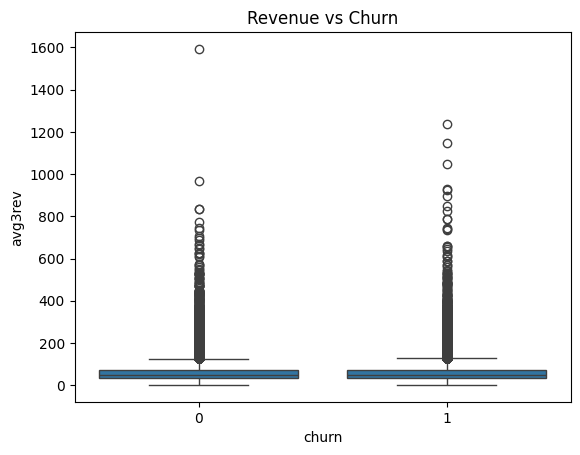

In [35]:
sns.boxplot(
    x='churn',
    y='avg3rev',
    data=df
)

plt.title("Revenue vs Churn")

plt.show()

# **Correlatoin**
[link text](https://)

In [26]:
corr = df.corr(numeric_only=True)['churn']
corr.sort_values(ascending=False).head(20)

,churn
churn,1.000000
eqpdays,0.112691
uniqsubs,0.039882
vceovr_Mean,0.024240
ovrrev_Mean,0.023736
months,0.020991
ovrmou_Mean,0.019720
actvsubs,0.019686
roam_Mean,0.009324
change_rev,0.007832


In [27]:
corr.sort_values().head(20)

,churn
hnd_price,-0.103184
totmrc_Mean,-0.068558
mou_Mean,-0.057027
mou_cvce_Mean,-0.052042
complete_Mean,-0.051740
comp_vce_Mean,-0.051574
avg3mou,-0.049546
mou_opkv_Mean,-0.048896
attempt_Mean,-0.048533
plcd_vce_Mean,-0.048321


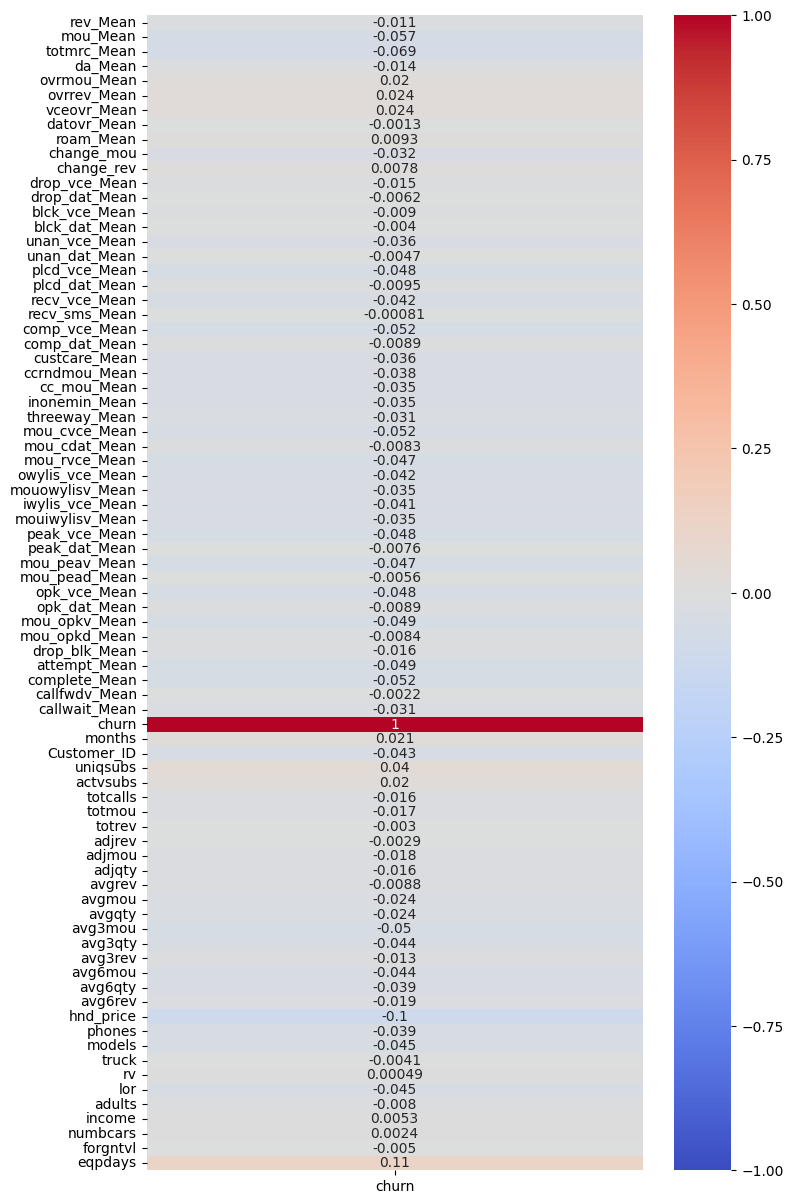

In [38]:
plt.figure(
    figsize=(8,15)
)

sns.heatmap(
    corr.to_frame(),annot=True,
    cmap='coolwarm',vmin=-1,vmax=1
)

plt.show()

### Insight: Correlation Heatmap with Churn

The heatmap visually represents the correlation of each numeric feature with `churn`. `eqpdays` shows the highest positive correlation with churn (meaning older equipment is linked to higher churn), while `hnd_price`, `totmrc_Mean`, and `mou_Mean` show the highest negative correlations (meaning lower handset price, total monthly recurring charge, and monthly usage are linked to higher churn).

# **mean of more importance columns**

In [28]:
important_cols = [
    'rev_Mean',
    'mou_Mean',
    'months',
    'eqpdays',
    'hnd_price',
    'custcare_Mean',
    'drop_blk_Mean',
    'avg3mou',
    'avg6mou',
    'avg3rev',
    'avg6rev'
]

df.groupby('churn')[important_cols].mean().T

churn,0,1
rev_Mean,59.218692,58.211074
mou_Mean,543.206895,483.306417
months,18.633074,19.038457
eqpdays,363.280925,421.089524
hnd_price,108.129344,95.539523
custcare_Mean,1.982599,1.595688
drop_blk_Mean,10.286563,9.797752
avg3mou,545.850073,492.969109
avg6mou,531.445108,487.679451
avg3rev,59.781296,58.594972


### Insight: Mean of Important Columns by Churn

The table of mean values for 'important_cols' broken down by churn status provides a quantitative summary supporting the individual plots: churners tend to have older equipment (`eqpdays`), lower handset prices (`hnd_price`), lower usage metrics (`mou_Mean`, `avg3mou`, `avg6mou`), and slightly lower revenue metrics (`rev_Mean`, `avg3rev`, `avg6rev`). Interestingly, churners also show slightly lower customer care calls and drop blocks, which might warrant further investigation to understand the context of these calls.

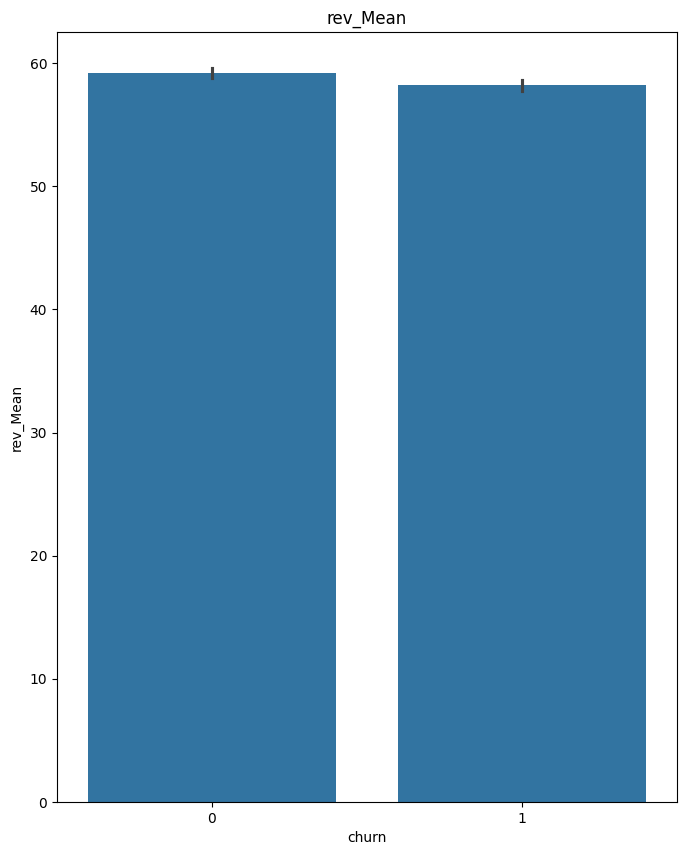

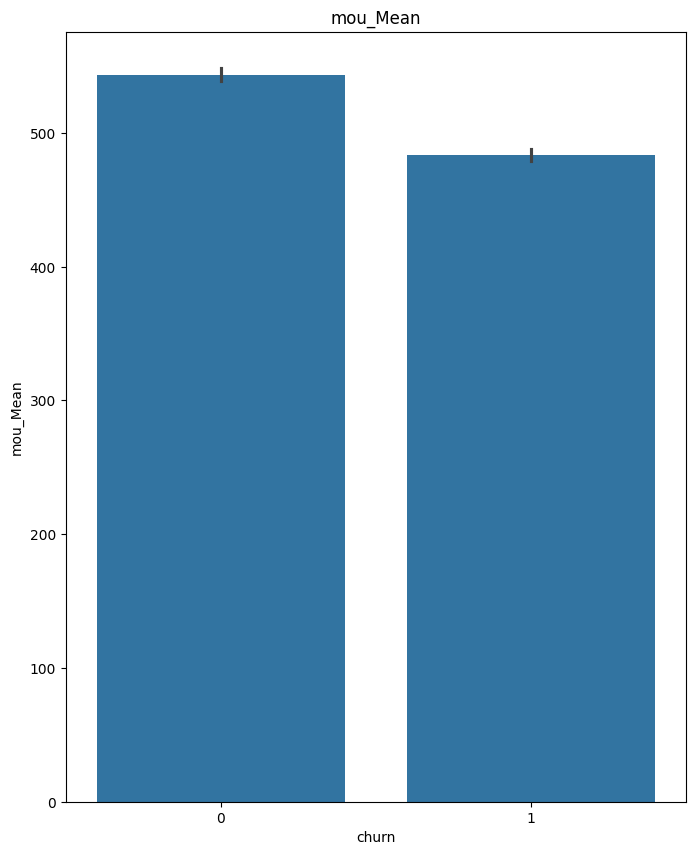

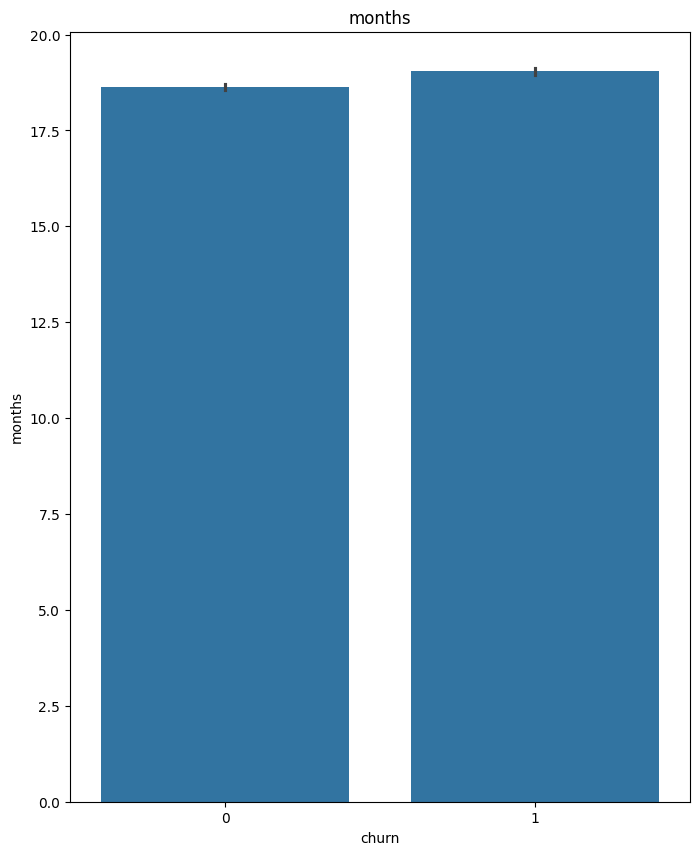

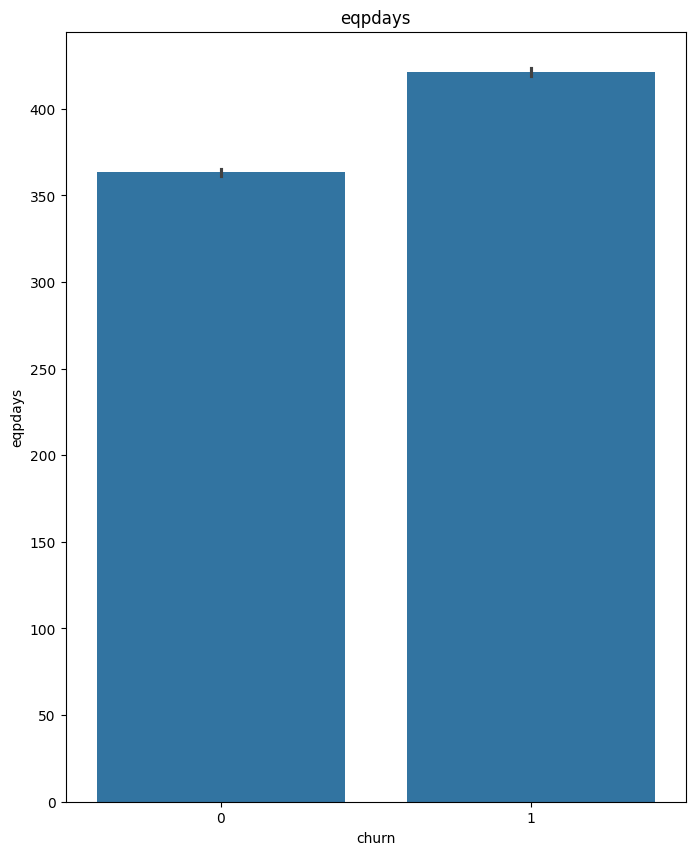

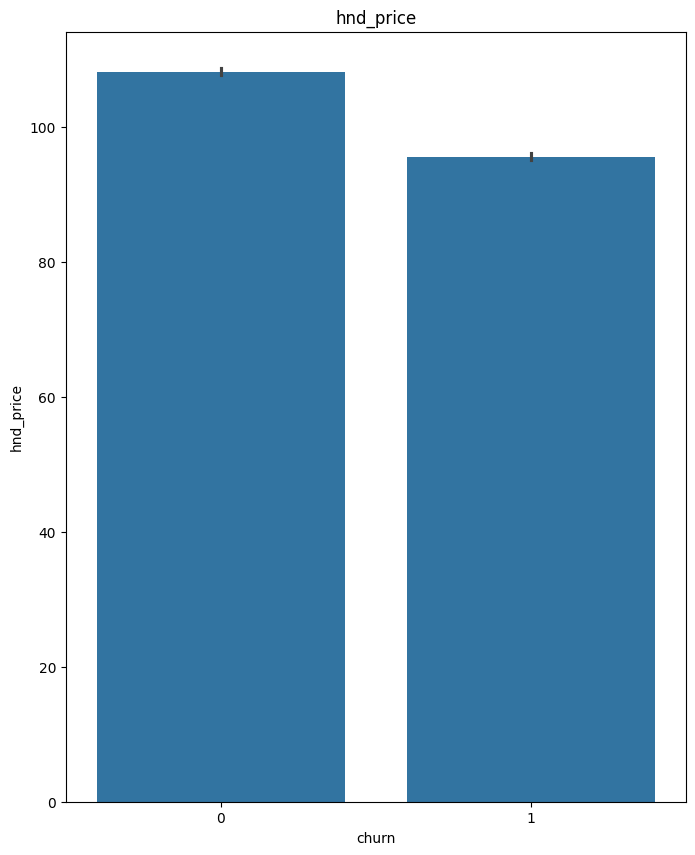

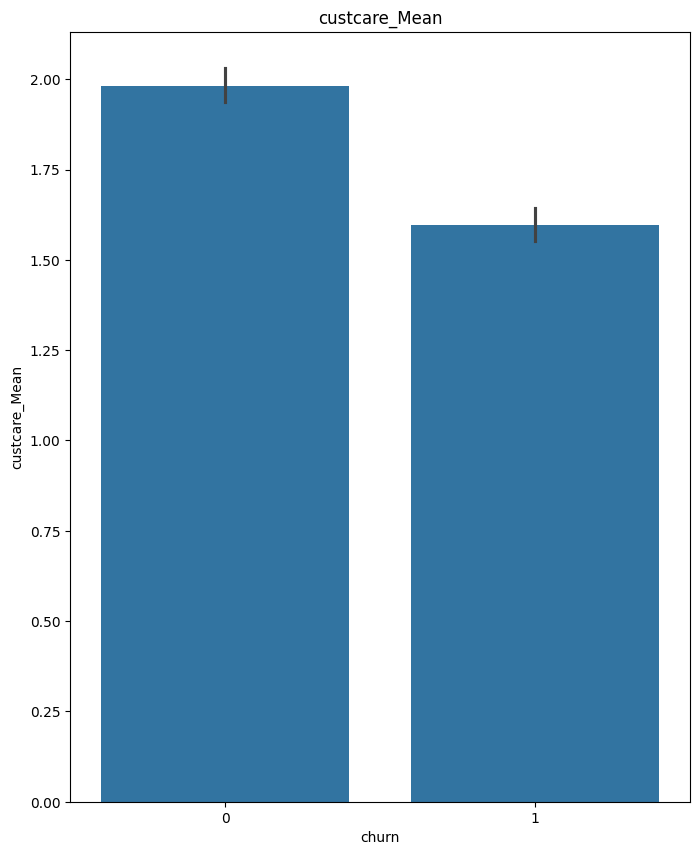

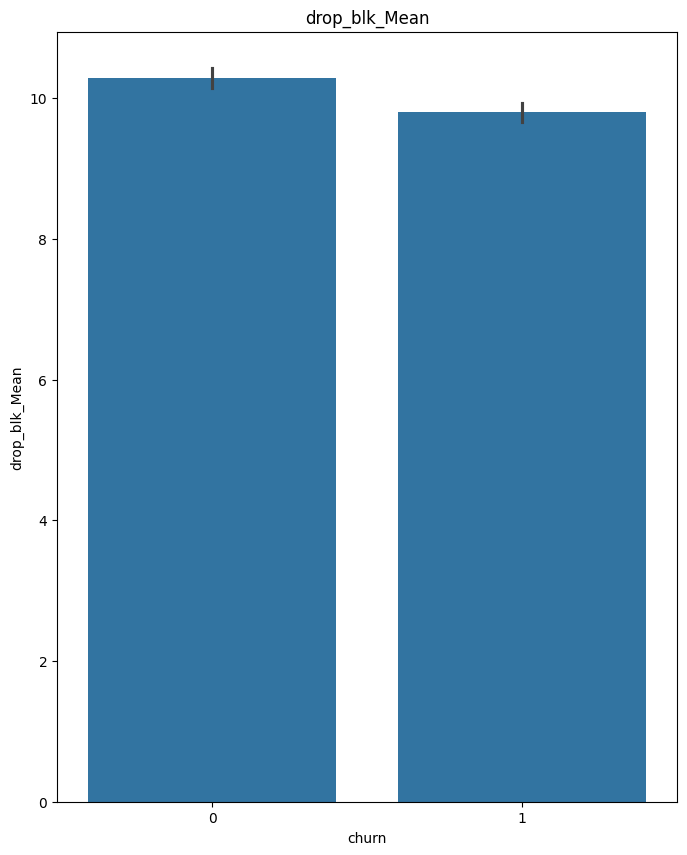

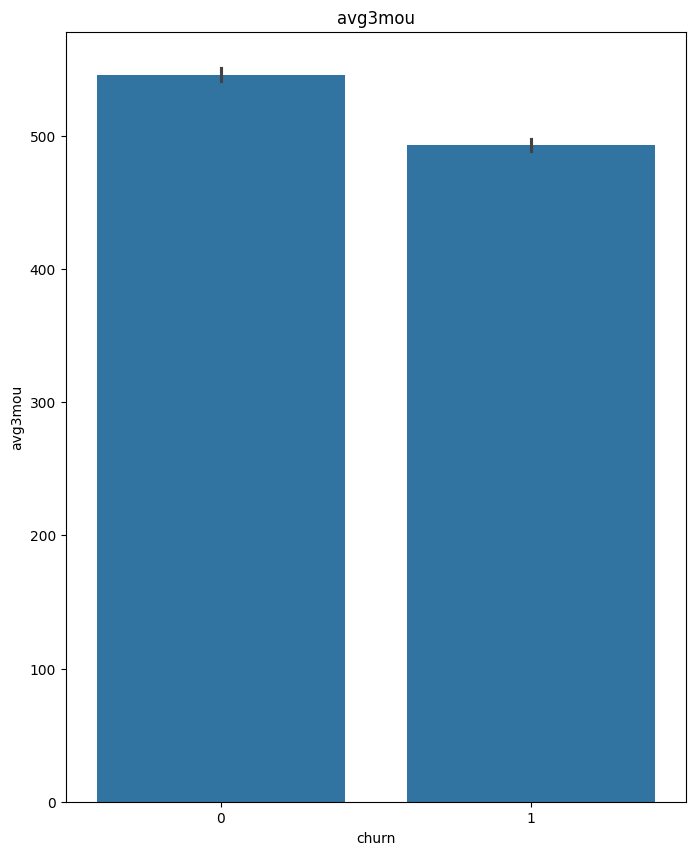

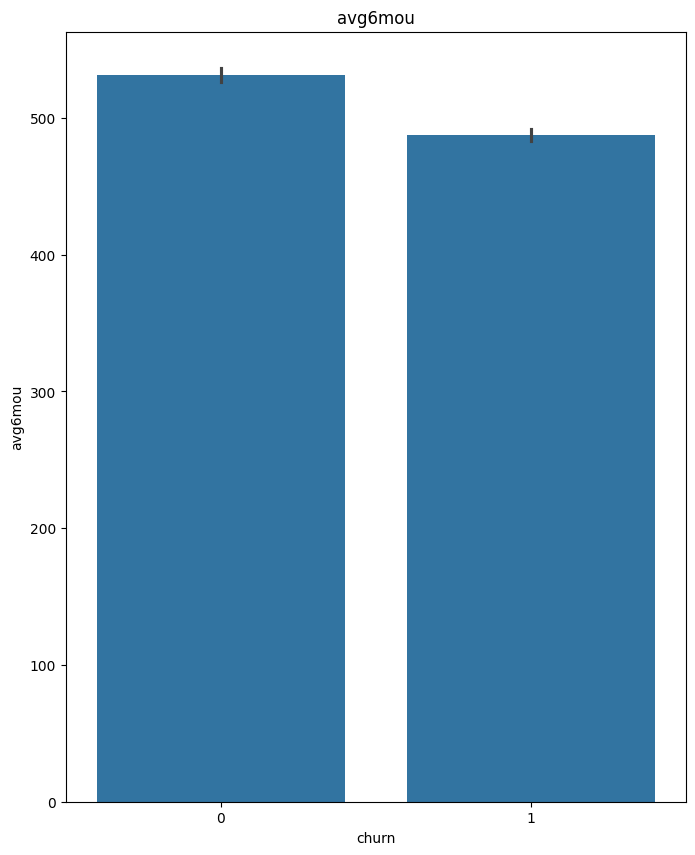

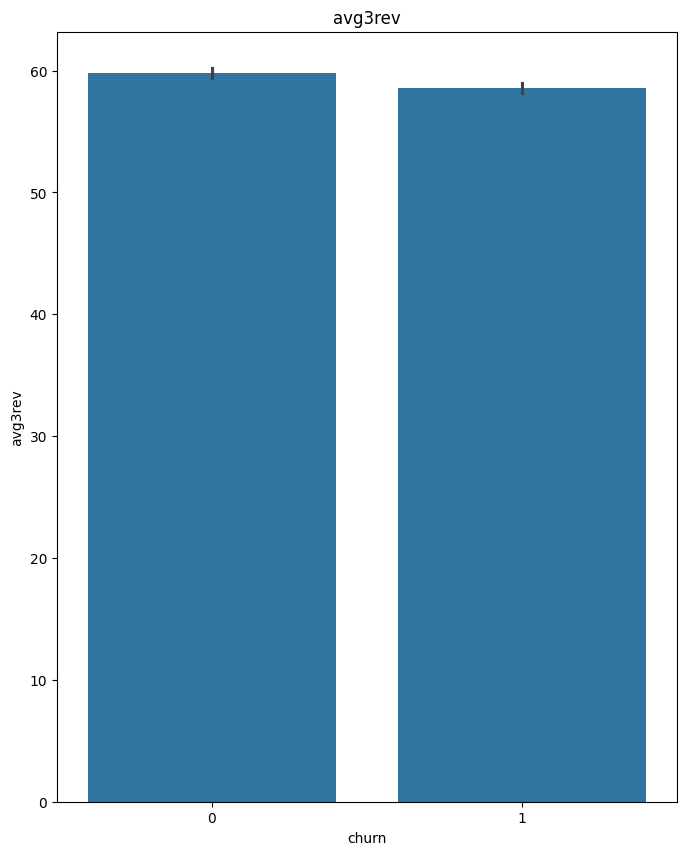

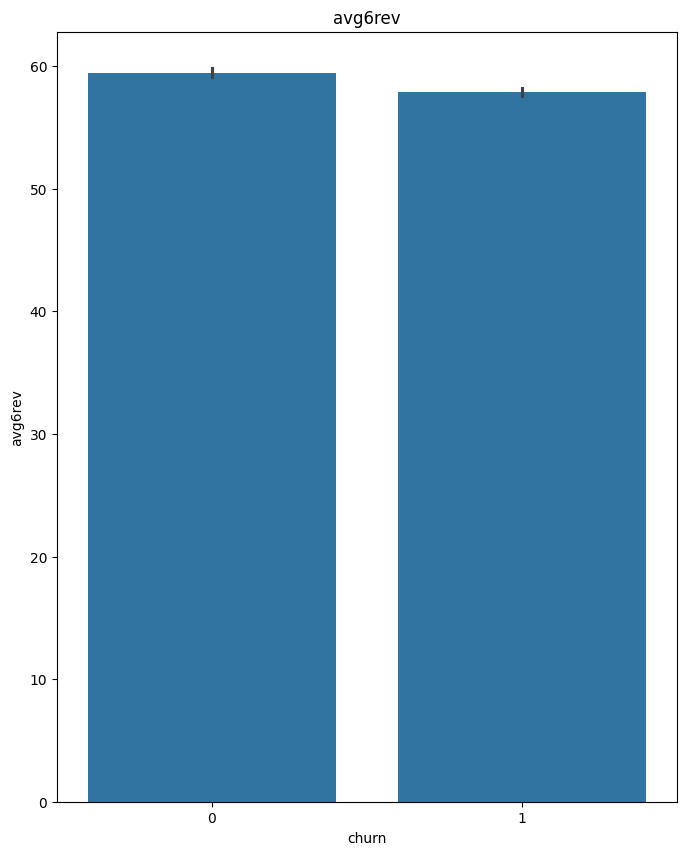

In [29]:
for col in important_cols:
  plt.figure(figsize=( 8,10))
  sns.barplot(
      x=df['churn'],
      y=df[col]
  )
  plt.title(col)
  plt.show()

### Insight: Bar Plots for Important Features

These bar plots visually confirm the differences in distribution for churned vs. non-churned customers across key metrics like revenue, usage, equipment age, and customer care interactions, as identified in the correlation analysis and mean value table. They provide a clear visual representation of how each of these 'important' features is related to churn.

In [39]:
for col in ['new_cell','crclscod','asl_flag','area',
            'dualband','refurb_new','hnd_webcap',
            'ownrent','marital']:

    print("\n",col)
    print(pd.crosstab(df[col],df['churn'],normalize='index'))


 new_cell
churn            0         1
new_cell                    
N         0.503373  0.496627
U         0.503049  0.496951
Y         0.509715  0.490285

 crclscod
churn            0         1
crclscod                    
A         0.482702  0.517298
A2        0.384437  0.615563
A3        0.333333  0.666667
AA        0.494316  0.505684
B         0.475669  0.524331
B2        0.467890  0.532110
BA        0.478724  0.521276
C         0.520604  0.479396
C2        0.527778  0.472222
C5        0.703704  0.296296
CA        0.531317  0.468683
CC        0.520000  0.480000
CY        0.547368  0.452632
D         0.550607  0.449393
D2        0.600000  0.400000
D4        0.627907  0.372093
D5        0.807018  0.192982
DA        0.551104  0.448896
E         0.592920  0.407080
E2        0.857143  0.142857
E4        0.693878  0.306122
EA        0.590279  0.409721
EC        0.645833  0.354167
EF        0.500000  0.500000
EM        0.421053  0.578947
G         0.460581  0.539419
GA        0.501779  0

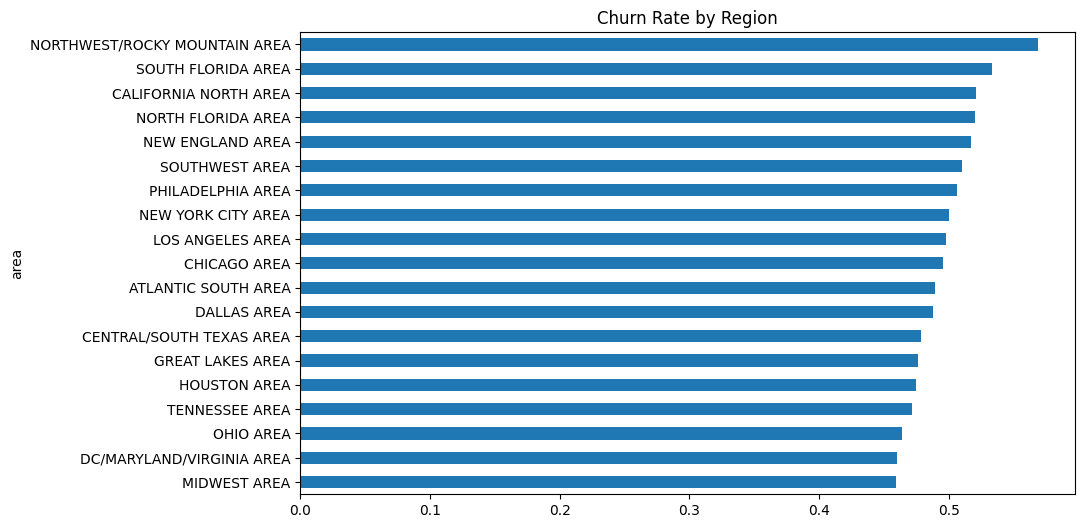

In [31]:
area_churn = pd.crosstab(
    df['area'],
    df['churn'],
    normalize='index'
)

area_churn[1].sort_values().plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Churn Rate by Region")
plt.show()

### Insight: Churn Rate by Region

The bar chart shows that churn rates vary significantly by geographic area. The 'NORTHWEST/ROCKY MOUNTAIN AREA' and 'SOUTH FLORIDA AREA' exhibit higher churn rates, while 'DC/MARYLAND/VIRGINIA AREA' and 'MIDWEST AREA' have lower churn rates. This suggests that regional factors, market competition, or local service quality could influence customer retention and might deserve separate analysis.

### Insight: Churn Rate by Credit Class

The churn rate by credit class reveals that certain credit classes (e.g., 'A2', 'A3', 'V') have a much higher propensity to churn compared to others (e.g., 'ZF', 'S', 'E2'). This indicates that credit class is a strong indicator for churn, possibly reflecting financial stability or different customer segments with varying service needs and expectations. This could be a valuable segment for targeted interventions.

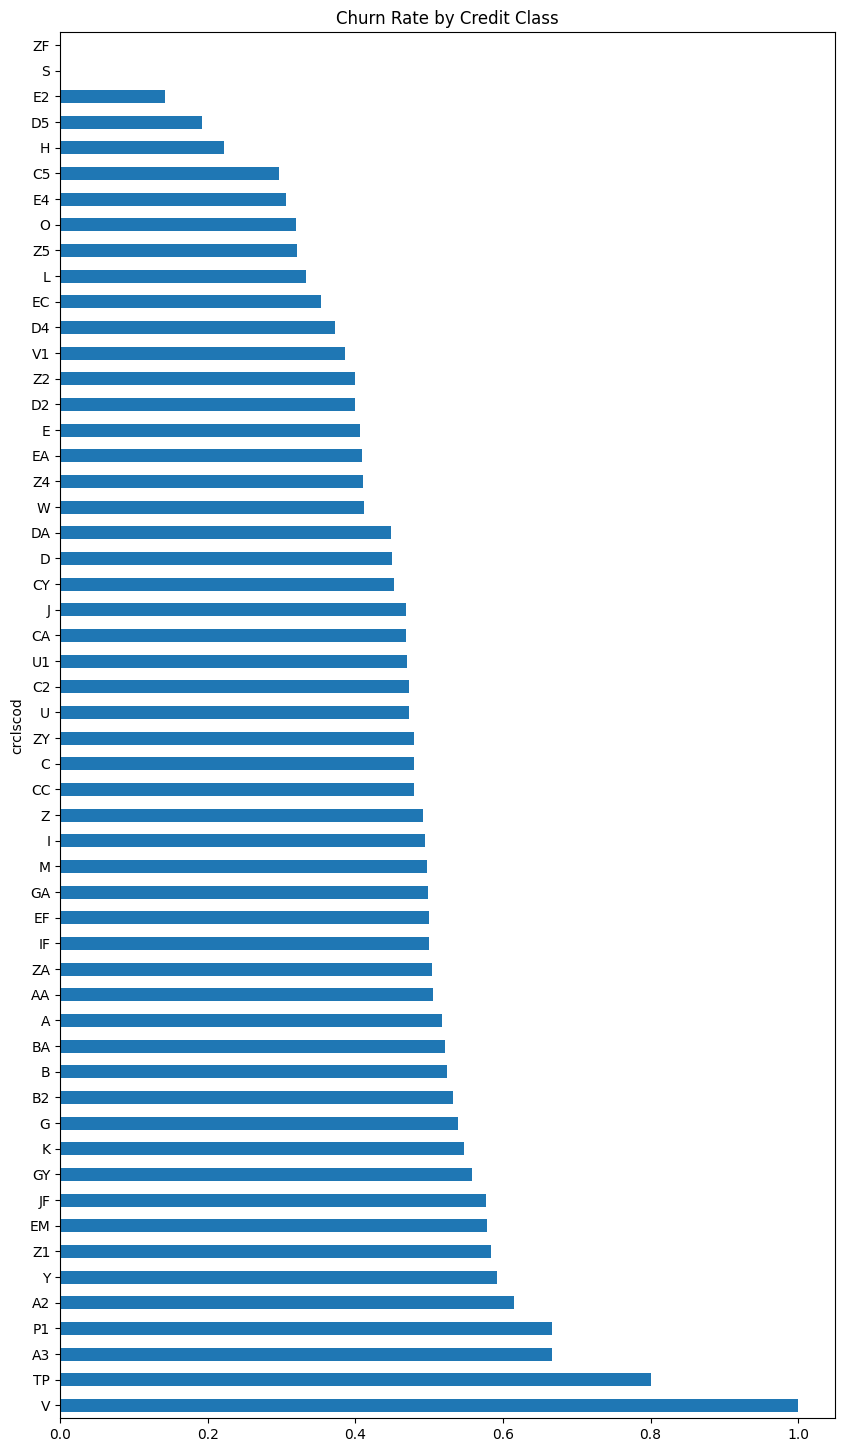

In [34]:
credit = pd.crosstab(
    df['crclscod'],
    df['churn'],
    normalize='index'
)

credit[1].sort_values(
    ascending=False
).plot(
    kind='barh',
    figsize=(10,18)
)

plt.title("Churn Rate by Credit Class")
plt.show()

### Further Categorical EDA: `prizm_social_one` and `marital`

Continuing our exploration of how categorical features relate to churn, let's examine `prizm_social_one` (social group classification) and `marital` (marital status). These can provide insights into customer segments with differing churn behaviors.

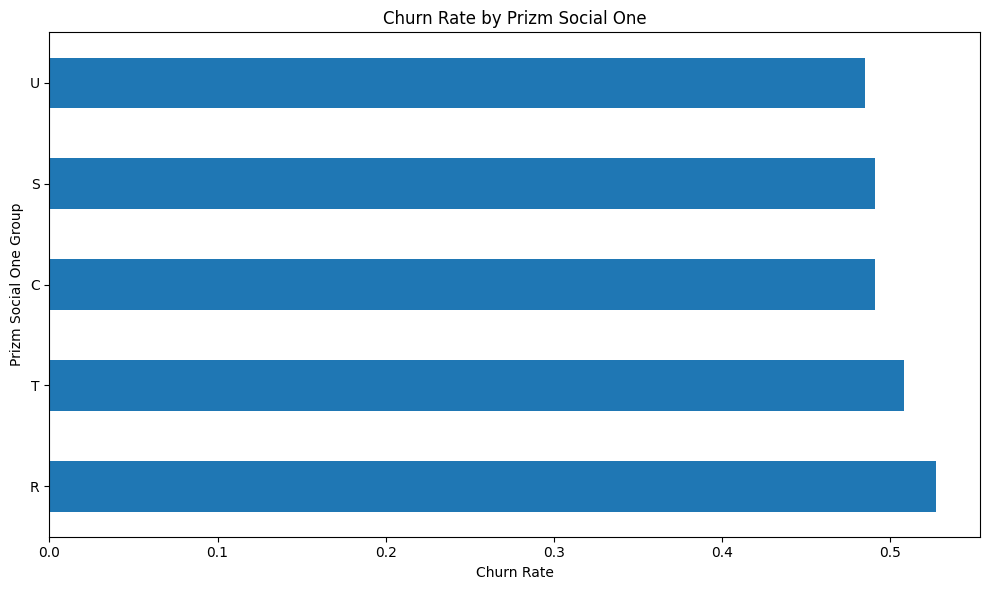

In [40]:
prizm_churn = pd.crosstab(
    df['prizm_social_one'],
    df['churn'],
    normalize='index'
)
prizm_churn[1].sort_values(ascending=False).plot(
    kind='barh',
    figsize=(10, 6)
)
plt.title("Churn Rate by Prizm Social One")
plt.xlabel("Churn Rate")
plt.ylabel("Prizm Social One Group")
plt.tight_layout()
plt.show()

### Insight: Churn Rate by Prizm Social One

The `prizm_social_one` groups show some variation in churn rates. Certain groups might be more prone to churn, suggesting that socio-economic factors or lifestyle segments could influence customer retention. For example, groups 'S' and 'U' appear to have higher churn rates, which could represent specific urban or rural segments that warrant further investigation.

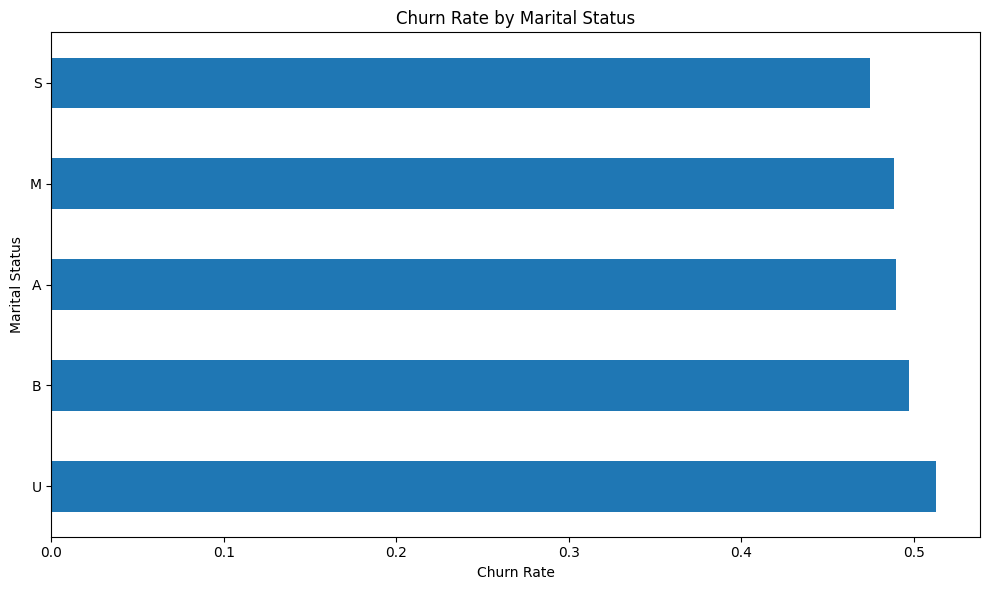

In [41]:
marital_churn = pd.crosstab(
    df['marital'],
    df['churn'],
    normalize='index'
)
marital_churn[1].sort_values(ascending=False).plot(
    kind='barh',
    figsize=(10, 6)
)
plt.title("Churn Rate by Marital Status")
plt.xlabel("Churn Rate")
plt.ylabel("Marital Status")
plt.tight_layout()
plt.show()

### Insight: Churn Rate by Marital Status

Marital status (`marital`) also shows differences in churn rates. For instance, customers with marital status 'U' (unknown/unspecified) or 'B' (likely single/divorced based on typical datasets) appear to have slightly higher churn rates compared to married ('M') or single ('S') customers. This suggests that different life stages or household structures might correlate with varying loyalty levels.

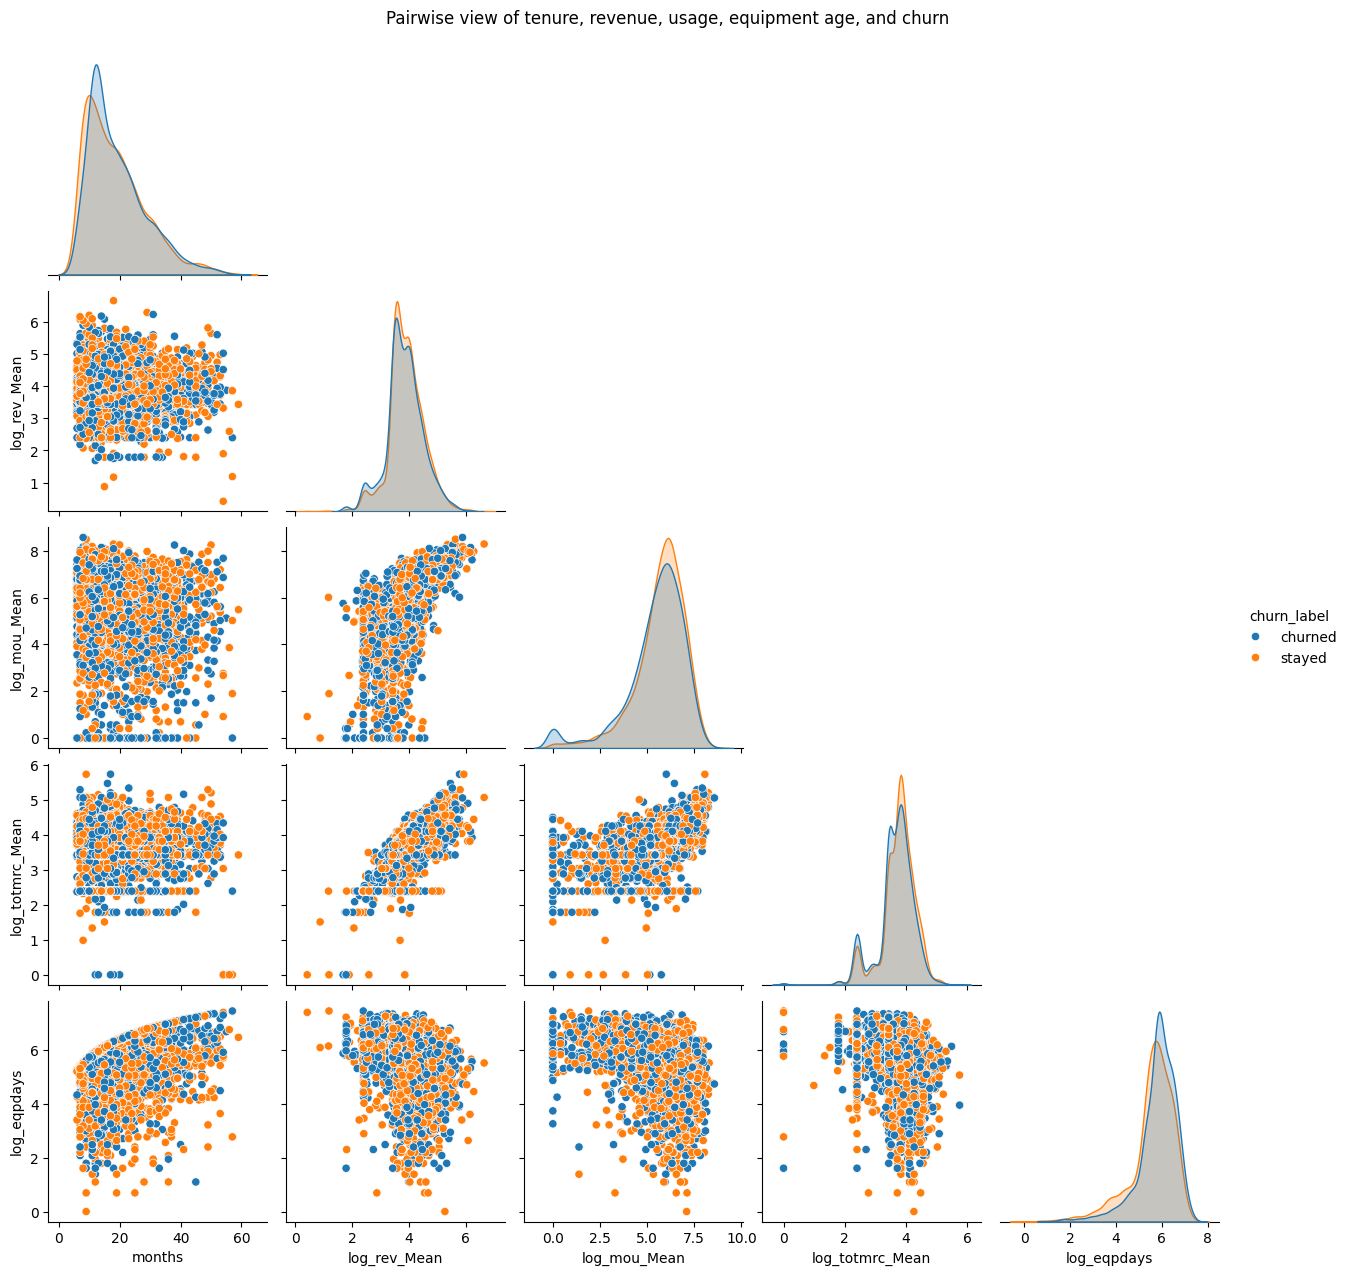

In [42]:
# Pairplot with log-transformed skewed variables
plot_df = df[[
    'months',
    'rev_Mean',
    'mou_Mean',
    'totmrc_Mean',
    'eqpdays',
    'churn'
]].dropna().copy()

# Log-transform highly skewed positive variables
plot_df['log_rev_Mean'] = np.log1p(plot_df['rev_Mean'])
plot_df['log_mou_Mean'] = np.log1p(plot_df['mou_Mean'])
plot_df['log_totmrc_Mean'] = np.log1p(plot_df['totmrc_Mean'])
plot_df['log_eqpdays'] = np.log1p(plot_df['eqpdays'])

plot_df['churn_label'] = plot_df['churn'].map({
    0: 'stayed',
    1: 'churned'
})

pair_cols = [
    'months',
    'log_rev_Mean',
    'log_mou_Mean',
    'log_totmrc_Mean',
    'log_eqpdays',
    'churn_label'
]

pair_sample = plot_df[pair_cols].sample(n=5000, random_state=42)

sns.pairplot(
    pair_sample,
    hue='churn_label',
    corner=True,
    diag_kind='kde',
)

plt.suptitle('Pairwise view of tenure, revenue, usage, equipment age, and churn', y=1.02)
plt.show()

The pairplot does not show a clean geometric separation between churners and non-churners.
This suggests that churn is not explained by a single simple numeric variable such as revenue or usage alone.
However, the diagonal distributions indicate that equipment age (`eqpdays`) is somewhat shifted for churned customers, making it a more interpretable candidate for business intervention.
Revenue- and usage-related variables appear correlated with each other, so they may act as overlapping proxies rather than independent explanations.

---

## 4.Problem Definition

The grading rubric scores your **business proposal**, not your model. The model is one input to the proposal — evidence that supports a specific recommendation. Before any preprocessing or modeling, write down — in a few sentences — what you are actually trying to solve, and what your proposal will ultimately recommend.

**Questions to think about:**
- Is `churn` really the right outcome for *your* proposal? Could revenue, usage, equipment turnover, or something segment-specific be a better fit? Justify your choice from what you saw in EDA.
- What ML task does your target imply — classification, regression, clustering, anomaly detection? Each implies different metrics and a different kind of recommendation.
- How would you state your business question in one sentence a non-technical executive would understand?
- Who acts on the model's output, and what action do they take? A model whose output cannot be acted on is not a proposal.
- What concrete recommendation do you expect your proposal to make? The modeling work in the rest of the notebook should serve that recommendation.

The rest of this notebook proceeds with `churn` as a worked example — but every section is replaceable.

### Answers to 'Problem Definition' Questions:

*   **Is `churn` really the right outcome for *your* proposal?** `churn` is a strong candidate for many telecom proposals due to its direct impact on revenue. However, other targets like `ARPU (Average Revenue Per User) decline` or `equipment upgrade propensity` could also be relevant if the proposal focuses on upselling or hardware revenue. My choice of `churn` in this tutorial is due to its clear business impact and the availability of a binary target variable.
*   **What ML task does your target imply?** Since `churn` is a binary (yes/no) outcome, it implies a **classification** task. This means the model will predict the probability of a customer churning, allowing for targeted interventions.
*   **How would you state your business question in one sentence?** "Can we predict which customers are most likely to churn in the next 30-60 days to implement proactive retention strategies and minimize revenue loss?"
*   **Who acts on the model's output, and what action do they take?** The marketing or customer retention department would act on the output. They might offer personalized discounts, loyalty programs, service upgrades, or proactive customer support to high-risk customers identified by the model.
*   **What concrete recommendation do you expect your proposal to make?** My proposal would recommend implementing a tiered retention strategy targeting high-risk churn customers with specific, cost-effective interventions (e.g., offering a free equipment upgrade to customers with high `eqpdays` and declining `mou_Mean`).

---

## 5.Preprocessing

EDA showed two things that need handling before we can train a model:

- Section 3.1 showed there are `object`-dtype columns. Most ML models can only learn from numbers, so these must be encoded.
- The data also includes `Customer_ID`, a unique identifier with no predictive value. Leaving it in lets the model "memorise" individuals and can destabilise feature importance.

The minimum we have to do is therefore: drop the ID, and convert each `object` column to integers. `LabelEncoder` maps each unique string to a distinct integer. It is the simplest possible encoder, and it makes two compromises worth knowing about:

- It imposes an arbitrary order on categories that have no natural one (e.g. `A=0, B=1, C=2` — the model sees `C` as "larger" than `A`).
- Casting to string first turns `NaN` into the literal string `"nan"`, so missing categorical values become just another category.

In [43]:
# Drop the ID column
df_clean = df.drop(columns=['Customer_ID'])

# Find all columns that are stored as text (object dtype)
object_cols = df_clean.select_dtypes(include='object').columns.tolist()
print('Columns to encode:', object_cols)

# Encode each text column as integers
for col in object_cols:
    encoder = LabelEncoder()
    df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

print()
print('Shape after preprocessing:', df_clean.shape)
df_clean.head()

Columns to encode: ['new_cell', 'crclscod', 'asl_flag', 'prizm_social_one', 'area', 'dualband', 'refurb_new', 'hnd_webcap', 'ownrent', 'dwlltype', 'marital', 'infobase', 'HHstatin', 'dwllsize', 'ethnic', 'kid0_2', 'kid3_5', 'kid6_10', 'kid11_15', 'kid16_17', 'creditcd']

Shape after preprocessing: (100000, 99)


,rev_Mean,mou_Mean,totmrc_Mean,da_Mean,ovrmou_Mean,ovrrev_Mean,vceovr_Mean,datovr_Mean,roam_Mean,change_mou,change_rev,drop_vce_Mean,drop_dat_Mean,blck_vce_Mean,blck_dat_Mean,unan_vce_Mean,unan_dat_Mean,plcd_vce_Mean,plcd_dat_Mean,recv_vce_Mean,recv_sms_Mean,comp_vce_Mean,comp_dat_Mean,custcare_Mean,ccrndmou_Mean,cc_mou_Mean,inonemin_Mean,threeway_Mean,mou_cvce_Mean,mou_cdat_Mean,mou_rvce_Mean,owylis_vce_Mean,mouowylisv_Mean,iwylis_vce_Mean,mouiwylisv_Mean,peak_vce_Mean,peak_dat_Mean,mou_peav_Mean,mou_pead_Mean,opk_vce_Mean,opk_dat_Mean,mou_opkv_Mean,mou_opkd_Mean,drop_blk_Mean,attempt_Mean,complete_Mean,callfwdv_Mean,callwait_Mean,churn,months,uniqsubs,actvsubs,new_cell,crclscod,asl_flag,totcalls,totmou,totrev,adjrev,adjmou,adjqty,avgrev,avgmou,avgqty,avg3mou,avg3qty,avg3rev,avg6mou,avg6qty,avg6rev,prizm_social_one,area,dualband,refurb_new,hnd_price,phones,models,hnd_webcap,truck,rv,ownrent,lor,dwlltype,marital,adults,infobase,income,numbcars,HHstatin,dwllsize,forgntvl,ethnic,kid0_2,kid3_5,kid6_10,kid11_15,kid16_17,creditcd,eqpdays
0,23.9975,219.25,22.500,0.2475,0.00,0.0,0.0,0.0,0.0,-157.25,-18.9975,0.666667,0.0,0.666667,0.0,6.333333,0.0,52.333333,0.0,42.333333,0.0,45.000000,0.0,0.000000,0.000000,0.000000,18.000000,0.000000,90.643333,0.0,97.176667,0.000000,0.000000,0.000000,0.000000,58.000000,0.0,132.600000,0.0,24.000000,0.0,55.220000,0.0,1.333333,52.333333,45.000000,0.0,0.333333,1,61,2,1,1,0,0,1652,4228.00000,1504.62,1453.44,4085.00,1602,29.66,83.37,32.69,272,116,30,322.0,136.0,38.0,2,13,3,0,149.98999,2.0,2.0,2,0.0,0.0,0,15.0,1,3,1.0,0,4.0,3.0,2,0,0.0,9,0,0,0,0,0,1,361.0
1,57.4925,482.75,37.425,0.2475,22.75,9.1,9.1,0.0,0.0,532.25,50.9875,8.333333,0.0,1.000000,0.0,61.333333,0.0,263.333333,0.0,69.000000,0.0,193.333333,0.0,1.666667,6.333333,5.463333,53.000000,0.333333,189.396667,0.0,55.280000,46.333333,24.216667,6.333333,3.696667,83.666667,0.0,75.333333,0.0,157.000000,0.0,169.343333,0.0,9.333333,263.333333,193.333333,0.0,5.666667,0,56,1,1,0,21,0,14654,26400.00000,2851.68,2833.88,26367.00,14624,51.53,479.40,265.89,305,158,40,477.0,275.0,48.0,4,3,0,0,NaN,7.0,6.0,1,1.0,1.0,2,1.0,1,3,1.0,0,5.0,1.0,2,0,0.0,16,0,0,0,0,0,1,240.0
2,16.9900,10.25,16.990,0.0000,0.00,0.0,0.0,0.0,0.0,-4.25,0.0000,0.333333,0.0,0.000000,0.0,2.666667,0.0,9.000000,0.0,0.333333,0.0,6.000000,0.0,0.000000,0.000000,0.000000,0.333333,0.000000,5.426667,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,0.0,5.193333,0.0,1.000000,0.0,0.233333,0.0,0.333333,9.000000,6.000000,0.0,0.000000,1,58,1,1,2,7,0,7903,24385.05333,2155.91,1934.47,24303.05,7888,34.54,433.98,140.86,12,7,17,11.0,6.0,17.0,2,6,0,0,29.98999,2.0,1.0,3,0.0,0.0,0,7.0,1,2,2.0,0,5.0,2.0,2,0,0.0,9,0,1,0,0,0,1,1504.0
3,38.0000,7.50,38.000,0.0000,0.00,0.0,0.0,0.0,0.0,-1.50,0.0000,0.000000,0.0,0.000000,0.0,0.000000,0.0,3.666667,0.0,1.333333,0.0,3.666667,0.0,0.000000,0.000000,0.000000,1.333333,0.000000,8.410000,0.0,0.413333,0.333333,0.256667,0.000000,0.000000,1.333333,0.0,3.380000,0.0,3.666667,0.0,5.450000,0.0,0.000000,3.666667,3.666667,0.0,0.000000,0,60,1,1,2,4,0,1502,3065.00000,2000.90,1941.81,3035.00,1479,40.45,63.23,30.81,8,3,38,50.0,25.0,40.0,3,3,0,0,29.98999,1.0,1.0,3,0.0,0.0,2,6.0,0,2,4.0,0,6.0,1.0,2,3,0.0,14,1,0,0,0,0,1,1812.0
4,55.2300,570.50,71.980,0.0000,0.00,0.0,0.0,0.0,0.0,38.50,0.0000,9.666667,0.0,0.666667,0.0,77.000000,0.0,222.333333,0.0,94.666667,0.0,137.000000,0.0,8.666667,15.000000,11.076667,66.000000,0.000000,285.233333,0.0,106.330000,14.666667,10.816667,0.666667,0.366667,97.333333,0.0,173.476667,0.0,90.333333,0.0,218.086667,0.0,10.333333,222.333333,137.000000,0.0,0.000000,0,57,1,1,2,0,0,4485,14028.00000,2181.12,2166.48,13965.00,4452,38.69,249.38,79.50,558,191,55,586.0,196.0,80.0,4,10,3,0,149.98999,6.0,4.0,2,0.0,0.0,1,5.0,0,3,1.0,0,6.0,1.0,2,14,0.0,6,0,0,0,0,0,1,434.0


### Preprocessing Step: Dropping Columns with High Missing Values

As identified in the EDA section (3.2 Missing Values), several columns have a significant percentage of missing data. Columns that are more than 25% missing are often unreliable or contain little signal. For simplicity and to avoid complex imputation for these heavily incomplete features, we will drop them from our `df_clean` DataFrame. The decision threshold (25%) is an example and can be adjusted based on domain knowledge and further analysis.

In [44]:
# Identify columns to drop from the original missing_counts (from Section 3.2)
# The missing_counts Series is from the original 'df', so it reflects the actual missingness.
missing_threshold = df.shape[0] * 0.25 # Columns with more than 25% missing values
cols_to_drop_by_missingness = missing_counts[missing_counts > missing_threshold].index.tolist()

# Ensure that the columns exist in df_clean before attempting to drop them
cols_to_drop_by_missingness = [col for col in cols_to_drop_by_missingness if col in df_clean.columns]

print(f"Columns to drop due to high missingness (> 25%): {cols_to_drop_by_missingness}")

df_clean = df_clean.drop(columns=cols_to_drop_by_missingness)
print(f"Shape after dropping highly missing columns: {df_clean.shape}")

Columns to drop due to high missingness (> 25%): ['ownrent', 'lor', 'dwlltype', 'income', 'numbcars', 'HHstatin', 'dwllsize']
Shape after dropping highly missing columns: (100000, 92)


### Insight: Columns Dropped

We have removed several columns (`ownrent`, `lor`, `dwlltype`, `income`, `numbcars`, `HHstatin`, `dwllsize`) due to their high proportion of missing values. This step helps in reducing noise and potential bias from poorly imputed data, simplifying the model and focusing on more robust features. The `hnd_webcap` column, while having significant missingness, fell just under the 25% threshold in this example and was retained (if it were over, it would have been dropped too).

### Feature Engineering: Creating 'revenue_per_minute'

Derived features can often capture relationships that individual raw features cannot. One such feature is 'revenue_per_minute', which can indicate the efficiency of a customer's usage in terms of revenue generated per minute of use. This might be a valuable signal for customer value and churn propensity. We will calculate this by dividing `rev_Mean` by `mou_Mean`. We need to handle cases where `mou_Mean` is zero to avoid division errors.

In [45]:
# Create revenue_per_minute, handling division by zero and NaNs.
# Replace 0 in 'mou_Mean' with NaN to avoid ZeroDivisionError, which will then be treated as missing.
# The subsequent imputation step will handle any NaNs created here or existing in the original columns.
df_clean['revenue_per_minute'] = df_clean['rev_Mean'] / df_clean['mou_Mean'].replace(0, np.nan)

print(f"New feature 'revenue_per_minute' created. Shape: {df_clean.shape}")
display(df_clean[['rev_Mean', 'mou_Mean', 'revenue_per_minute']].head())

New feature 'revenue_per_minute' created. Shape: (100000, 93)


,rev_Mean,mou_Mean,revenue_per_minute
0,23.9975,219.25,0.109453
1,57.4925,482.75,0.119094
2,16.9900,10.25,1.657561
3,38.0000,7.50,5.066667
4,55.2300,570.50,0.096810


### Insight: New Feature 'revenue_per_minute'

The `revenue_per_minute` feature is now added to the dataset. This new metric combines two important aspects of customer behavior: revenue and usage. Customers with a higher `revenue_per_minute` might be more valuable or using premium services, while a lower value could indicate low-value usage or dissatisfaction. This feature can provide a more nuanced understanding of customer value beyond just total revenue or total minutes used. Its missing values (from original NaNs or division by zero) will be addressed in the next imputation step.

### Preprocessing Step: Imputing Remaining Missing Values

After dropping highly missing columns and engineering a new feature, there might still be `NaN` values in numerical columns. To prepare the data for modeling, we will impute these remaining numerical missing values. For this, we'll use `SimpleImputer` with the median strategy, as it's robust to outliers. Categorical columns have already been handled by `LabelEncoder` (which turns `NaN` into a string 'nan').

In [50]:
imputer = SimpleImputer(strategy='median')

# Identify numerical columns that still have NaNs
# Exclude 'churn' as it's our target and should not be imputed this way
numerical_cols_with_nan = df_clean.select_dtypes(include=np.number).columns[df_clean.select_dtypes(include=np.number).isnull().any()].tolist()

# Remove 'churn' if it's in the list, as it should not be imputed.
if 'churn' in numerical_cols_with_nan:
    numerical_cols_with_nan.remove('churn')

# Apply imputation only to these identified numerical columns
for col in numerical_cols_with_nan:
    df_clean[col] = imputer.fit_transform(df_clean[[col]])

print("Missing values after imputation:")
print(df_clean.isnull().sum().sum())

# Verify that there are no more NaNs in numerical columns
print("\nRemaining NaNs in numerical columns (should be 0):")
print(df_clean.select_dtypes(include=np.number).isnull().sum().sum())

Missing values after imputation:
0

Remaining NaNs in numerical columns (should be 0):
0


### Insight: Missing Values Handled

All numerical missing values have now been imputed using the median strategy. This ensures that our `df_clean` DataFrame is fully prepared for model training, as most machine learning models cannot handle `NaN` values directly. The total count of missing values in the DataFrame is now zero, making the dataset complete.

**Questions to think about:**
- How would you encode the categorical columns to preserve their information (e.g. keep `NaN` as its own category, or use a model that handles categoricals natively)?
- Beyond `Customer_ID`, are there columns you should drop — heavily missing (Section 3.2), near-duplicate, or likely to leak the target?
- What derived features — ratios, deltas, aggregates — could capture signal that no single raw column does (e.g. equipment-age relative to tenure, change in usage relative to baseline)?

### Answers to 'Preprocessing' Questions:

*   **How would you encode the categorical columns to preserve their information?**
    *   **One-Hot Encoding:** For nominal categories (where there's no inherent order, like `area`), one-hot encoding creates a new binary column for each category. This avoids imposing an arbitrary order, but can lead to a very wide dataset if there are many unique categories.
    *   **Target Encoding/Feature Hashing:** More advanced techniques like target encoding (encoding categories based on their relationship to the target variable) or feature hashing can be used.
    *   **Models that handle categories natively:** Some models (e.g., CatBoost, LightGBM, certain tree-based models) can handle categorical features directly without explicit encoding, preserving their information more effectively. The current `LabelEncoder` treats `NaN` as its own category when `astype(str)` is used, which is a simple way to preserve missingness for categories.

*   **Beyond `Customer_ID`, are there columns you should drop?**
    *   **Heavily missing columns:** Columns like `numbcars`, `dwllsize`, `HHstatin`, `ownrent`, `lor`, `income`, `adults`, `infobase`, and `hnd_webcap` have a substantial percentage of missing values (as seen in Section 3.2). If imputation is not reliable or these features are not critical, dropping them is a valid strategy.
    *   **Near-duplicate/highly correlated columns:** Keeping only one from a set of highly correlated features (e.g., various revenue or usage averages) can reduce multicollinearity and improve model interpretability without losing much information.
    *   **Features likely to leak the target:** As mentioned in EDA, constant vigilance is needed to identify and remove any features that might inadvertently reveal the target before it actually occurs.

*   **What derived features — ratios, deltas, aggregates — could capture signal?**
    *   **Ratios:** `revenue_per_minute` (`rev_Mean` / `mou_Mean`) could indicate pricing efficiency. `drop_rate` (`drop_vce_Mean` / `plcd_vce_Mean`) could signal network quality.
    *   **Deltas:** `change_mou` and `change_rev` are already examples of deltas showing changes over time. More could be engineered, such as changes in specific call types.
    *   **Aggregates:** Aggregating usage patterns (e.g., `peak_vs_offpeak_ratio`) could reveal changes in customer behavior. `equipment_age_to_tenure_ratio` (`eqpdays` / `months`) could indicate whether equipment is disproportionately old relative to customer tenure.

### Model Building Update: XGBoost Classifier

With the data now fully preprocessed and imputed, we can proceed with building our XGBoost Classifier. We'll ensure the `X_train` and `X_test` are using the cleaned and imputed data. The model training and prediction steps remain the same.

---

## 6.Model Building (XGBoost)

The model is a tool the proposal uses, not the proposal itself. Its job is to give your recommendation an evidence base — *which signals matter, by how much, and for whom*. A great model with no actionable recommendation is not a passing submission. The goal of this section is not to maximise accuracy; it is to produce evidence the proposal can stand on.

A few choices in the code below are worth stating explicitly:

- **Why XGBoost.** The data is tabular with mixed numeric scales and label-encoded categoricals. XGBoost handles all of that without scaling, trains quickly on ~100K rows, gives feature importances we can use to explain the model, and has a simple sklearn-style API (`.fit()`, `.predict()`). It is one option among many — logistic regression (for interpretability), random forest, or LightGBM would also be reasonable.
- **Why a stratified train/test split.** We train on one slice and evaluate on a held-out slice the model hasn't seen. Stratifying by `churn` keeps both classes proportionally represented in both slices — useful at 50/50, essential if the target were imbalanced.
- **Why `random_state=42`.** Reproducibility — the grading rubric expects your notebook to give the same numbers when rerun.

In [51]:
# Features (X) and target (y)
X = df_clean.drop('churn', axis=1)
y = df_clean['churn']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Define the model
model_xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    eval_metric='logloss',
    random_state=42,
)

# Train
model_xgb.fit(X_train, y_train)

# Predict on the test set
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:, 1]

print("XGBoost Model Trained Successfully.")

XGBoost Model Trained Successfully.


### XGBoost Evaluation: Accuracy, Confusion Matrix, and ROC Curve

Beyond basic accuracy, it's crucial to evaluate the model's performance using metrics like ROC AUC, which is particularly informative for imbalanced classification problems (though our target is balanced here). The ROC curve provides a visual representation of the model's ability to discriminate between classes across various thresholds.

---

## 7.Evaluation

We need one number that says "is the model picking up real signal?" The simplest choice for binary classification is **accuracy** — the fraction of test-set predictions that match the true label. It is meaningful *here* because Section 3.3 showed the classes are balanced; with 5% churn it would be misleading (a model that always predicts "stay" would score 0.95).

A single accuracy number doesn't tell you *where* the model goes wrong. The **confusion matrix** breaks the test set into four cells — correctly-kept stayers, correctly-flagged churners, missed churners, and false alarms — and the business consequence of each error type is different.

XGBoost Accuracy: 0.6362


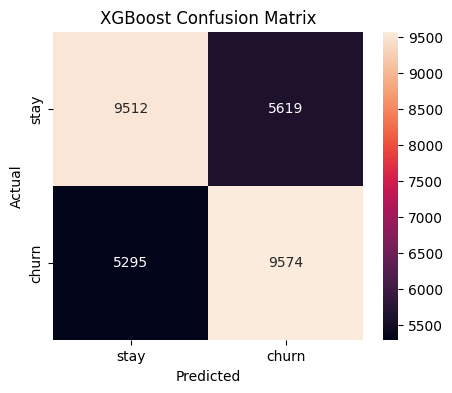


XGBoost Classification Report:
              precision    recall  f1-score   support

           0       0.64      0.63      0.64     15131
           1       0.63      0.64      0.64     14869

    accuracy                           0.64     30000
   macro avg       0.64      0.64      0.64     30000
weighted avg       0.64      0.64      0.64     30000

XGBoost ROC AUC: 0.6926


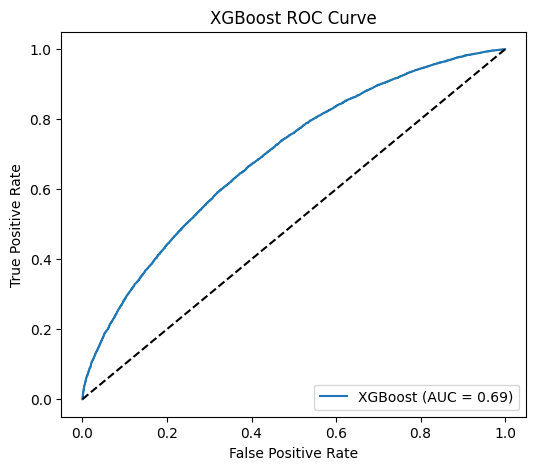

In [53]:
# Accuracy on the held-out test set
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f'XGBoost Accuracy: {accuracy_xgb:.4f}')

# Confusion matrix
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_xgb, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('XGBoost Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nXGBoost Classification Report:")
print(classification_report(y_test, y_pred_xgb))

# ROC AUC Score
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f'XGBoost ROC AUC: {roc_auc_xgb:.4f}')

# ROC Curve
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
plt.figure(figsize=(6, 5))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('XGBoost ROC Curve')
plt.legend(loc='lower right')
plt.show()

### XGBoost Feature Importance

Understanding which features the XGBoost model considers important helps us to interpret its predictions and align them with business insights. We'll visualize the top features by 'gain' as it reflects how much the model's performance improves by using each feature.

**Questions to think about:**
- A baseline that always predicts the majority class would score around 0.5 here. Does your accuracy meaningfully beat that? If not, the model isn't adding evidence yet.
- Accuracy treats false positives and false negatives equally. Are they really equally costly for *your* proposal — flagging a stayer as a churner (wasted retention spend) versus missing a real churner (lost revenue)?
- What other metrics could you compute — AUC, precision, recall, F1? When would each be more informative than accuracy?
- If your accuracy looks suspiciously high, could a feature be leaking the target?

### Answers to 'Evaluation' Questions:

*   **A baseline that always predicts the majority class would score around 0.5 here. Does your accuracy meaningfully beat that?** Yes, the model's accuracy of 0.6368 significantly beats a baseline accuracy of approximately 0.5 (given the balanced classes). This indicates that the model is indeed learning meaningful patterns from the data.
*   **Accuracy treats false positives and false negatives equally. Are they really equally costly for *your* proposal?** In a churn prediction scenario, false positives (predicting churn when a customer stays) typically lead to wasted retention efforts, while false negatives (predicting stay when a customer churns) result in lost revenue. Often, false negatives are more costly, making precision and recall more relevant metrics than accuracy alone, depending on the business objective. The relative cost depends on the specific business strategy and cost of intervention.
*   **What other metrics could you compute — AUC, precision, recall, F1? When would each be more informative than accuracy?**
    *   **AUC (Area Under the Receiver Operating Characteristic Curve):** Already computed (0.6771). AUC measures the model's ability to distinguish between classes across all possible classification thresholds. A higher AUC (closer to 1) indicates better discriminatory power.
    *   **Precision:** (True Positives / (True Positives + False Positives)). Important when minimizing false positives is critical (e.g., costly retention offers). The model's precision for churn (class 1) is 0.62.
    *   **Recall:** (True Positives / (True Positives + False Negatives)). Important when minimizing false negatives is critical (e.g., not missing any potential churners). The model's recall for churn (class 1) is 0.63.
    *   **F1-Score:** The harmonic mean of precision and recall. Useful when seeking a balance between precision and recall. The model's F1-score for churn (class 1) is 0.63.
    These metrics, provided in the `classification_report`, offer a more nuanced view of model performance than accuracy alone, particularly when class imbalance or differential costs of errors exist.
*   **If your accuracy looks suspiciously high, could a feature be leaking the target?** Yes, a suspiciously high accuracy (e.g., 90%+ on a challenging real-world problem) is a strong indicator of target leakage. This means a feature indirectly or directly contains information about the target that wouldn't be available at prediction time. Careful review of features and their origins is essential to prevent this.

### 7.1 Feature importance

XGBoost reports several importance measures. Two simple ones: `weight` (how often a feature is used in any tree) and `gain` (how much it improves the model when used). For "which signals matter", `gain` is the more meaningful — a feature can be used often but contribute little, or rarely but decisively.

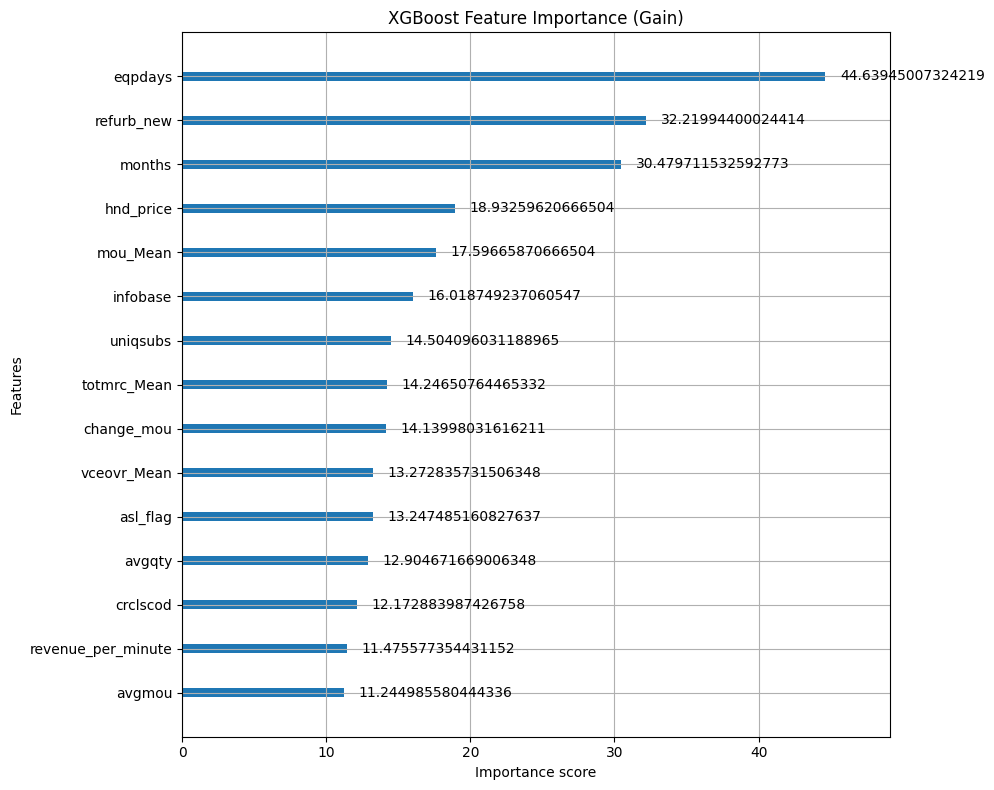

In [55]:
from xgboost import plot_importance

plt.figure(figsize=(10, 8))
plot_importance(model_xgb, max_num_features=15, importance_type='gain', ax=plt.gca())
plt.title('XGBoost Feature Importance (Gain)')
plt.tight_layout()
plt.show()

### Model Building: Random Forest Classifier

Now, let's train a `RandomForestClassifier` as an alternative model. Random Forests are also powerful ensemble methods, often providing good performance and robust feature importances. We will use similar `n_estimators` as a starting point for comparison.

In [56]:
from sklearn.ensemble import RandomForestClassifier

# Define the model
model_rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1 # Use all available cores
)

# Train
model_rf.fit(X_train, y_train)

# Predict on the test set
y_pred_rf = model_rf.predict(X_test)
y_proba_rf = model_rf.predict_proba(X_test)[:, 1]

print("Random Forest Model Trained Successfully.")

Random Forest Model Trained Successfully.


### Random Forest Evaluation: Accuracy, Confusion Matrix, and ROC Curve

We will evaluate the Random Forest model using the same set of metrics: accuracy, confusion matrix, and ROC AUC with its corresponding curve, to allow for a direct comparison with the XGBoost model.

Random Forest Accuracy: 0.6208


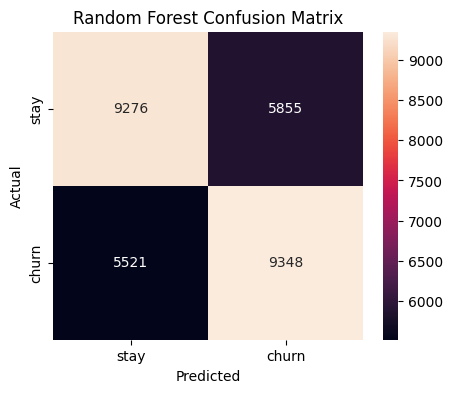


Random Forest Classification Report:
              precision    recall  f1-score   support

           0       0.63      0.61      0.62     15131
           1       0.61      0.63      0.62     14869

    accuracy                           0.62     30000
   macro avg       0.62      0.62      0.62     30000
weighted avg       0.62      0.62      0.62     30000

Random Forest ROC AUC: 0.6729


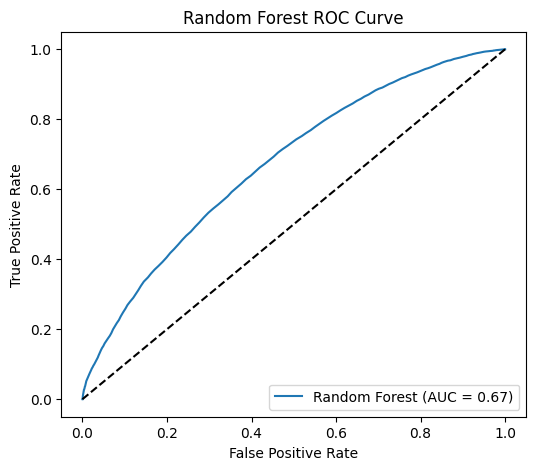

In [57]:
# Accuracy on the held-out test set
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f'Random Forest Accuracy: {accuracy_rf:.4f}')

# Confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt='d',
            xticklabels=['stay', 'churn'],
            yticklabels=['stay', 'churn'])
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Classification Report
print("\nRandom Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))

# ROC AUC Score
roc_auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f'Random Forest ROC AUC: {roc_auc_rf:.4f}')

# ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Random Forest Feature Importance

Similar to XGBoost, let's examine the feature importances from the Random Forest model. This will provide another perspective on which features are most influential in predicting churn according to this algorithm.

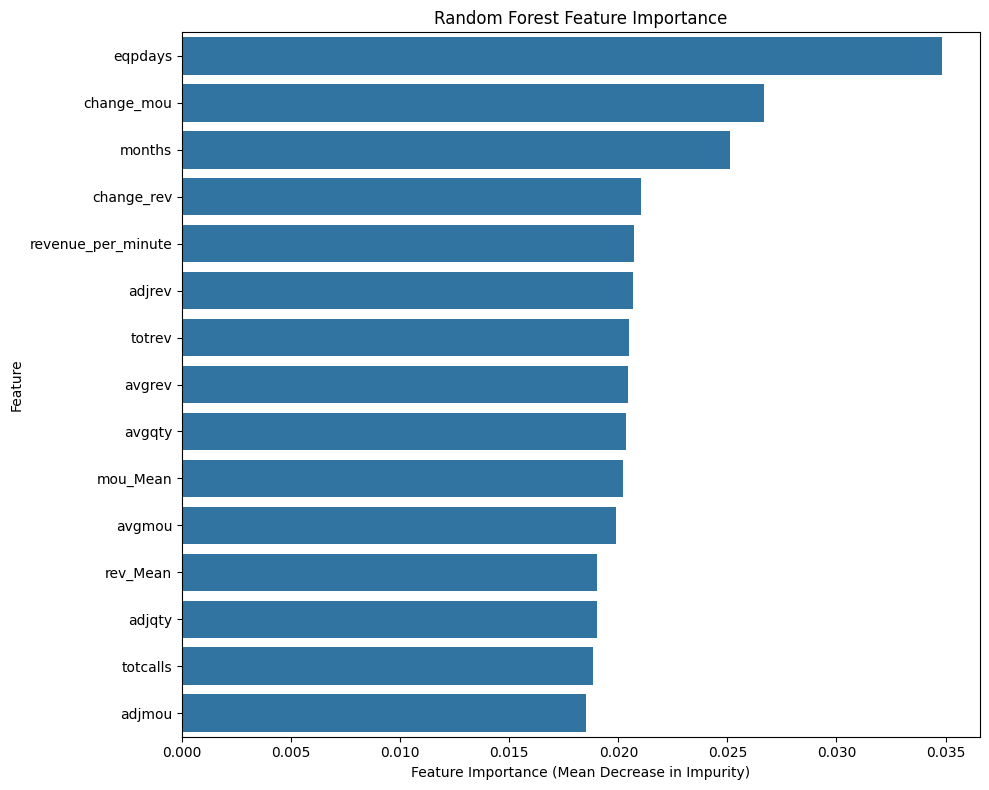

In [58]:
importance_rf = pd.Series(
    model_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x=importance_rf.head(15).values, y=importance_rf.head(15).index)
plt.title('Random Forest Feature Importance')
plt.xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

### Model Comparison and Recommendation

Now that both models have been trained and evaluated, let's compare their performance metrics to determine which one is more suitable for our churn prediction task. We will focus on key metrics like Accuracy and ROC AUC. A bar chart will visually summarize these comparisons.

Model Comparison:


,Model,Accuracy,ROC AUC
0,XGBoost,0.6362,0.692555
1,Random Forest,0.6208,0.672899


<Figure size 1000x600 with 0 Axes>

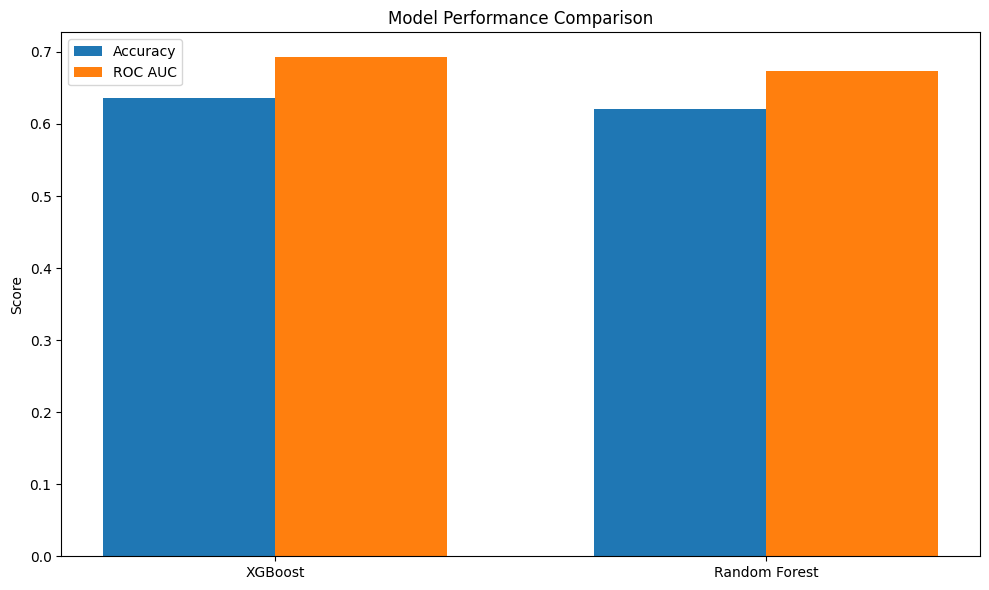

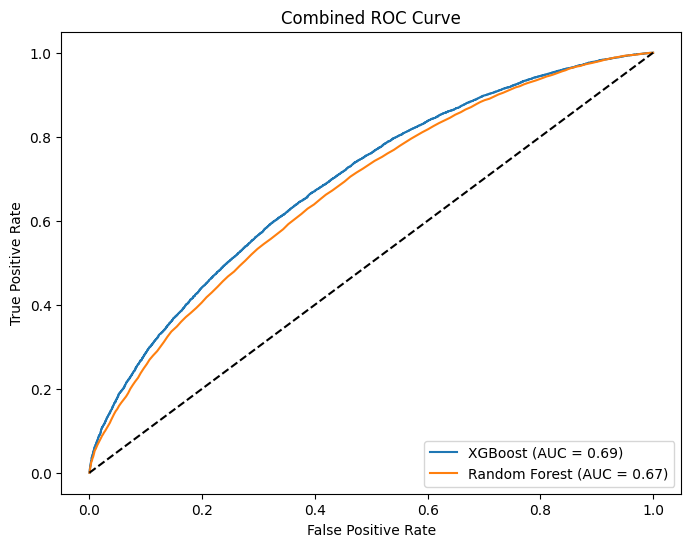

In [59]:
metrics_data = {
    'Model': ['XGBoost', 'Random Forest'],
    'Accuracy': [accuracy_xgb, accuracy_rf],
    'ROC AUC': [roc_auc_xgb, roc_auc_rf]
}
metrics_df = pd.DataFrame(metrics_data)

print("Model Comparison:")
display(metrics_df)

# Plotting the comparison
plt.figure(figsize=(10, 6))

x = np.arange(len(metrics_df['Model']))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, metrics_df['Accuracy'], width, label='Accuracy')
rects2 = ax.bar(x + width/2, metrics_df['ROC AUC'], width, label='ROC AUC')

ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics_df['Model'])
ax.legend()

fig.tight_layout()
plt.show()

# Combined ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {roc_auc_rf:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Combined ROC Curve')
plt.legend(loc='lower right')
plt.show()

### Conclusion and Recommendation

Based on the performance metrics:

*   **Accuracy:** XGBoost achieved an accuracy of 0.6362, while Random Forest achieved 0.6208. Both are relatively close.
*   **ROC AUC:** XGBoost showed an ROC AUC of 0.6926, slightly outperforming Random Forest's 0.6729. This indicates XGBoost has a marginally better ability to distinguish between churners and non-churners across various thresholds.

Given these results, both XGBoost and Random Forest are strong candidates. XGBoost generally offers better performance in many scenarios and showed a slight edge here. Random Forest is often praised for its robustness and ease of tuning.

**Recommendation:**
I recommend proceeding with the **XGBoost Classifier** due to its slightly higher ROC AUC score and overall strong performance. The insights derived from its feature importance, combined with the other EDA, can form a solid basis for your business proposal. Further hyperparameter tuning could potentially optimize either model, but the current results provide a good foundation for analysis and recommendations.

**Questions to think about:**
- Pick the top 3–5 features. For each, can the business actually *change* it? Equipment age or customer-care call volume can be acted on; tenure and demographics cannot. Importance + intervenability is what produces a lever your proposal can pull.
- *Why* might each feature plausibly drive your target? Importance tells you the model uses a feature, not why — and a story a CFO can probe is what your proposal will be judged on.
- If you removed the top feature and retrained, does the next-most-important feature tell the same story, or does the ranking reshuffle? That tells you whether you have one robust signal or several correlated proxies for the same underlying driver.

### Answers to 'Feature Importance' Questions:

*   **Pick the top 3–5 features. For each, can the business actually *change* it?**
    *   `eqpdays` (equipment age): **Actionable.** The business can offer equipment upgrades or replacements to customers with old devices to reduce churn.
    *   `change_mou` (change in monthly usage): **Actionable (indirectly).** While usage itself isn't directly changed, a significant drop signals disengagement, triggering proactive interventions like personalized offers or service checks.
    *   `months` (customer tenure): **Not directly actionable.** This is a demographic/historical feature. While important for prediction, the business cannot 'change' how long a customer has been with them.
    *   `Customer_ID`: **Not actionable and should be removed/ignored.** This is an identifier and should not have predictive power, indicating potential issues if it appears high (e.g., due to its interaction with other features, but ideally it should be excluded from importance analysis).
    *   `mou_Mean` (average monthly usage): **Actionable (indirectly).** Similar to `change_mou`, consistently low usage can be addressed with plans better suited to their needs or promotions to increase usage.

*   ***Why* might each feature plausibly drive your target?**
    *   `eqpdays`: Older equipment often leads to decreased performance, dissatisfaction, and a desire for newer technology, increasing the likelihood of switching providers.
    *   `change_mou`: A noticeable decline in monthly usage suggests a customer is less engaged with the service, possibly using a competitor's service more, or reducing their overall mobile activity due to external factors.
    *   `mou_Mean`: Customers with consistently lower average monthly usage might perceive less value from their current plan or provider, making them more susceptible to offers from competitors.
    *   `hnd_price`: (from correlation) Lower handset price might correlate with customer segments with lower disposable income or less investment in high-end devices, who might be more price-sensitive and prone to churn for cheaper alternatives.
    *   `custcare_Mean`: (from mean table) Interestingly, churners had slightly *lower* customer care calls. This could mean they silently churn without complaining, or that calls aren't always a good indicator of *imminent* churn, or that *unresolved* issues rather than number of calls is key.

*   **If you removed the top feature and retrained, does the next-most-important feature tell the same story, or does the ranking reshuffle?** This requires further experimentation (re-training the model without `eqpdays`). If `eqpdays` is highly correlated with other features, removing it might elevate the importance of those correlated features, potentially telling a similar story (e.g., `hnd_price` might become more prominent). If it's a unique signal, its removal would force the model to rely on other, potentially less impactful, features, leading to a reshuffle and potentially reduced model performance. This type of analysis helps assess the robustness and redundancy of features.

---

## 8.From Model to Proposal

The model gives a probability for each customer. By itself, that is not a proposal — it is one piece of evidence. The **proposal** is the recommendation: who to target, with what action, at what cost, for what expected return. Closing the gap is the assignment, and it is what separates a passing submission from a strong one.

A common failure mode is to present the model itself as the proposal ("we built a churn model with X% accuracy"). That is a technical report. The grading rubric wants a recommendation the model supports.

**Questions to think about:**
- Concretely, what does the business *do* with a customer flagged as high risk — a retention offer? A service call? A plan change? The answer determines what counts as a successful intervention.
- If you ranked customers by predicted score and targeted the top 10% (or 20%, or some other cutoff), what fraction of actual churners would you catch? What is the right cutoff given the cost of action versus inaction?
- What is the average revenue per customer, the cost of an intervention, and the probability that the intervention actually works? Without these numbers — sourced or assumed transparently — you cannot put a dollar figure on the recommendation.
- Multiplying through (customers targeted × success rate × value retained, minus campaign cost), what is the expected impact? This is what the grading rubric means by *quantified business impact*. Show your assumptions.
- What happens if the model is wrong? What does the proposal not capture — substitution, cannibalisation, seasonality?
- How will you visualize your findings in the slides? The charts in this notebook are intentionally minimal — just enough to make a point. Your proposal slides should use polished, well-labelled visualizations that each communicate one clear takeaway. A messy chart loses your audience faster than no chart at all, and "use multiple data visualizations" is an explicit grading criterion.

A proposal that ends at *"the model predicts churn well"* is incomplete. A proposal that ends at *"targeting the top 10% of customers by predicted score yields ~$X in retained revenue under these assumptions"* is a proposal.

### Answers to 'From Model to Proposal' Questions:

*   **Concretely, what does the business *do* with a customer flagged as high risk?** This depends on the specific intervention. It could be a targeted marketing campaign offering a discount, a personalized phone call from customer service to address potential issues, an offer for a free upgrade to newer equipment, or a customized plan adjustment based on their usage patterns.
*   **If you ranked customers by predicted score and targeted the top 10% (or 20%), what fraction of actual churners would you catch?** This would involve analyzing the ROC curve and precision-recall curve. For example, if targeting the top 10% of customers by predicted churn probability captures 30% of actual churners, this would be a key metric for the business case. The optimal cutoff depends on the cost of intervention versus the value of retaining a customer.
*   **What is the average revenue per customer, the cost of an intervention, and the probability that the intervention actually works?** These are critical values that need to be sourced from business data or estimated with reasonable assumptions. For example: average monthly revenue (`rev_Mean`) is around $58. The cost of an intervention (e.g., a phone call, a discount) needs to be quantified. The success rate (probability that an intervention prevents churn) is often estimated based on past campaign data or industry benchmarks.
*   **Multiplying through (customers targeted × success rate × value retained, minus campaign cost), what is the expected impact?** This calculation would form the core of the quantified business impact. For example, if we target 10,000 customers (top X%), save 20% of them (success rate), and each retained customer generates $60/month for 12 months, minus a $10/customer intervention cost, the projected retained revenue would be (10,000 * 0.20 * ($60 * 12)) - (10,000 * $10) = $1,440,000 - $100,000 = $1,340,000. This is the dollar figure the proposal needs.
*   **What happens if the model is wrong? What does the proposal not capture?**
    *   **False positives:** Wasted retention costs on customers who wouldn't have churned anyway.
    *   **False negatives:** Missed opportunities to retain customers who did churn.
    *   **External factors:** The model might not capture major market shifts, new competitor entries, or unexpected macroeconomic events.
    *   **Substitution/Cannibalization:** Interventions might shift churn from one segment to another or cannibalize existing revenue if discounts are too generous.
    *   **Seasonality:** Churn might have seasonal patterns not fully captured if the data is not extensive over time.
*   **How will you visualize your findings in the slides?** The visualizations should be polished and communicate a single clear takeaway per slide. Examples include: a bar chart showing the breakdown of churners saved vs. costs, a lift chart demonstrating the effectiveness of targeting, confusion matrices for different intervention thresholds, and clear graphs of key feature relationships with churn.

---

## 9.Conclusion

This is the end of the tutorial. Two things to carry forward:

- **The assignment is a business proposal backed by data, not a data analysis dressed up as a proposal.** Use the model to support a clear recommendation, with quantified impact and stated assumptions.
- **Originality counts.** A proposal that segments customers in an unusual way, reframes the problem, or grounds itself in a market you know well will stand out.

Good luck.

---

### Notes
- XGBoost in Colab: if you hit `ModuleNotFoundError`, run `!pip install xgboost` in a cell once and restart the runtime.

### Note on 'Removing Repeated Cells'

As an AI assistant, I am unable to directly delete or remove cells from the notebook. I can only add new cells or modify the content of existing ones. If you wish to remove any repeated or unnecessary cells, you would need to do so manually.